# 2D Photonic Crystal — $C_{4v}$ Diatomic (Cached Results)
Simulations are automatically skipped if results already exist on disk.
On first run, all simulations execute; on subsequent runs, only analysis and plotting are performed.

## Configuration

In [40]:
root = r"/zhome/2f/7/202918/phc_nzi"
src = r"/zhome/2f/7/202918/phc_nzi/src"
import sys
sys.path.append(root)
sys.path.append(src)

## Define the materials
from phc_nzi.photonic_crystal_maker import (Material, Geometry, PhotonicCrystal, 
                                        ScriptParam, ScriptParamVector3, BaseDielectricDistribution,
                                        HexagonalLattice)
import meep as mp
from phc_nzi.mpb_configurator import *
from phc_nzi.mpi_differential_evolution import MPIdeOptimizator
from phc_nzi.simulation_handler import LSFJobConfiguration, MPBDataOptions, Simulation
from phc_nzi.optimization_data_analyzer import OptimizationDataAnalyzer
from phc_nzi.simulation_viewer import SimulationViewer
from phc_nzi.lsf_sweeper import LSFSweeper

import numpy as np
import matplotlib.pyplot as plt
import os
import matplotlib.colors as colors
plt.rcParams["font.size"] = 15

T = 4
n_InP = 3.075*(1+2.7e-5*T)
print(n_InP)
eps_inp = round(n_InP**2,2)
print("Epsilon of InP: ", eps_inp)

inp = Material(epsilon = eps_inp)
air = Material(epsilon = 1)
## Simulation Name: 
name = "C4v_diatomic_holes_1"

## Define the geometry
radius1 = ScriptParam("r1", 0.3)
radius2 = ScriptParam("r2", 0.2)
height_supercell = 3
height_slab = ScriptParam("h", 0.4)
slab_block_size = ScriptParamVector3(1e20, 1e20, "h", z_def = 0.4)

## Define the lattice

lattice_2D = SquareLattice()
lattice_slab = SquareLattice(supercell_height= 4)

k_points = lattice_2D.get_high_symmetry_k_points(centered_in_gamma=True)
distance = 0.1
k_points_around_gamma = lattice_2D.get_k_points_around_gamma(distance = distance)

print(k_points)


center = mp.Vector3(0,0,0)


geom_2D = BaseDielectricDistribution(eps_bulk = eps_inp, eps_atoms=1).make_C4v_diatomic_B()
geom_slab = BaseDielectricDistribution(eps_bulk = eps_inp, eps_atoms = 1, height_slab=0.5).make_C4v_diatomic_B()


photonic_crystal_2D = PhotonicCrystal(lattice=lattice_2D, atoms=geom_2D)
photonic_crystal_slab = PhotonicCrystal(lattice=lattice_slab, atoms=geom_slab)

RESOLUTION = 32
## Define the simulation
configuration_options_2D = dict(
    resolution = RESOLUTION,
    num_bands=12,
    k_points=k_points["k_points_values"],
    k_points_interpolation_factor = 10,
    extra_runner_command = "fix-hfield-phase output-hfield output-efield",
)

configuration_options_2D_optimized = dict(
    resolution = RESOLUTION,
    num_bands=12,
    k_points=k_points_around_gamma["k_points_values"],
    k_points_interpolation_factor = 10,
    extra_runner_command = "fix-hfield-phase output-hfield output-efield",
)



configuration_options_slab = dict(
    resolution = RESOLUTION,
    num_bands=15,
    k_points=k_points["k_points_values"],
    k_points_interpolation_factor = 10,
    extra_runner_command = "(output-at-kpoint (vector3 0 0 0) fix-hfield-phase output-hfield)",
)

configuration_options_slab_centered = dict(
    resolution = RESOLUTION,
    num_bands=15,
    k_points=k_points_around_gamma["k_points_values"],
    k_points_interpolation_factor = 10,
    extra_runner_command = "(output-at-kpoint (vector3 0 0 0) fix-hfield-phase output-hfield)",
)


configuration_options_optimization = dict(
    resolution = RESOLUTION,
    num_bands=8,
    k_points = [mp.Vector3(0,0,0)],
    
)

configuration_options_sweep = dict( 
    resolution = RESOLUTION,
    num_bands=10,
    k_points=[mp.Vector3(0,0,0)],
)


mpb_configuration_2D = MPBSchemeConfigurator(photonic_crystal_2D, ["te", "tm"], **configuration_options_2D)
mpb_configuration_slab = MPBSchemeConfigurator(photonic_crystal_slab, ["zeven"], **configuration_options_slab)
mpb_configuration_2D_opt = MPBSchemeConfigurator(photonic_crystal_2D, ["te"], **configuration_options_optimization)
mpb_configuration_2D_optimized = MPBSchemeConfigurator(photonic_crystal_2D, ["te"], **configuration_options_2D_optimized)
mpb_configuration_2D_sweep = MPBSchemeConfigurator(photonic_crystal_2D, ["te"], **configuration_options_sweep)
mpb_configuration_slab_opt = MPBSchemeConfigurator(photonic_crystal_slab, ["zeven"], **configuration_options_optimization)
mpb_configuration_slab_sweep = MPBSchemeConfigurator(photonic_crystal_slab, ["zeven"], **configuration_options_sweep)
mpb_configuration_slab_opt_centered = MPBSchemeConfigurator(photonic_crystal_slab, ["zeven"], **configuration_options_slab_centered)

script_2D = mpb_configuration_2D.get_scheme_config(join_newline=True)
script_slab = mpb_configuration_slab.get_scheme_config(join_newline=True)
script_2D_opt = mpb_configuration_2D_opt.get_scheme_config(join_newline=True)
script_2D_optimized = mpb_configuration_2D_optimized.get_scheme_config(join_newline=True)
script_2D_sweep = mpb_configuration_2D_sweep.get_scheme_config(join_newline=True)
script_slab_opt = mpb_configuration_slab_opt.get_scheme_config(join_newline=True)
script_slab_sweep = mpb_configuration_slab_sweep.get_scheme_config(join_newline=True)
script_slab_opt_centered = mpb_configuration_slab_opt_centered.get_scheme_config(join_newline=True)




name_2D = name  + "_2D"
name_slab = name + "_slab"


name_2D_opt = name + "_2D_opt"
name_2D_sweep = name + "_2D_sweep"

name_slab_opt = name + "_slab_opt"
name_slab_sweep = name + "_slab_sweep"
name_slab_opt_centered = name + "_slab_opt_centered"

name_2D_optimized = name + "_2D_optimized"

data_rooth = "/work3/enrva/phc_nzi_data/MPB_data"
if not os.path.exists(data_rooth):
    os.makedirs(data_rooth)

simulation_2D = Simulation(
    simulation_name=name_2D,
    script = script_2D,
    directory= os.path.join(data_rooth, name_2D)
    )

simulation_2D_opt_456 = Simulation(
    simulation_name=name_2D_opt + "_456",
    script = script_2D_opt +"_456",
    directory= os.path.join(data_rooth, name_2D_opt + "_456")
    )

simulation_2D_opt_345 = Simulation(
    simulation_name=name_2D_opt + "_345",
    script = script_2D_opt +"_345",
    directory= os.path.join(data_rooth, name_2D_opt + "_345")
    )

simulation_2D_sweep = Simulation(
    simulation_name=name_2D_sweep,
    script = script_2D_sweep,
    directory= os.path.join(data_rooth, name_2D_sweep)
    )

simulation_2D_optimized = Simulation(
    simulation_name=name_2D_optimized,
    script = script_2D_optimized,
    directory= os.path.join(data_rooth, name_2D_optimized)
    )


simulation_slab = Simulation(
    simulation_name=name_slab,
    script = script_slab,
    directory= os.path.join(data_rooth, name_slab)
    )


simulation_slab_opt = Simulation(
    simulation_name=name_slab_opt,
    script = script_slab_opt,
    directory= os.path.join(data_rooth, name_slab_opt)  
    )

simulation_slab_opt_centered = Simulation(
    simulation_name=name_slab_opt_centered,
    script = script_slab_opt_centered,
    directory= os.path.join(data_rooth, name_slab_opt_centered)  
    )

simulation_slab_sweep = Simulation(
    simulation_name=name_slab_sweep,
    script = script_slab_sweep,
    directory= os.path.join(data_rooth, name_slab_sweep)  
    )






numproc= 32
pop = numproc // 2
lsf_config = LSFJobConfiguration(num_processors=numproc, span_option="hosts", span_value=1, queue="fotonano",   mem = "1GB")


3.0753321000000002
Epsilon of InP:  9.46
{'k_points_values': [Vector3<0.5, 0.0, 0.0>, Vector3<0.0, 0.0, 0.0>, Vector3<0.5, 0.5, 0.0>, Vector3<0.5, 0.0, 0.0>], 'k_points_labels': ['X', '$\\Gamma$', 'M', 'X']}
COMMANDS ['(define-param h 1e+20)', '(define-param r1 0.1)', '(define-param r2 0.2)']
COMMANDS ['(define-param h 0.5)', '(define-param r1 0.1)', '(define-param r2 0.2)']
COMMANDS ['(define-param h 1e+20)', '(define-param r1 0.1)', '(define-param r2 0.2)']
COMMANDS ['(define-param h 1e+20)', '(define-param r1 0.1)', '(define-param r2 0.2)']
COMMANDS ['(define-param h 1e+20)', '(define-param r1 0.1)', '(define-param r2 0.2)']
COMMANDS ['(define-param h 0.5)', '(define-param r1 0.1)', '(define-param r2 0.2)']
COMMANDS ['(define-param h 0.5)', '(define-param r1 0.1)', '(define-param r2 0.2)']
COMMANDS ['(define-param h 0.5)', '(define-param r1 0.1)', '(define-param r2 0.2)']


In [ ]:
import pandas as pd

# ── Result Caching Helpers ──────────────────────────────────────────────────
# These utilities check if simulation results already exist on disk,
# allowing the notebook to skip re-running expensive simulations.

def simulation_has_results(sim, polarization="te"):
    """Check if frequency .dat file exists (simulation ran + frequencies extracted)."""
    dat_file = os.path.join(sim.directory, f"{sim.simulation_name}.{polarization}.dat")
    return os.path.exists(dat_file)

def simulation_has_output(sim):
    """Check if .out file exists (simulation was executed)."""
    out_file = os.path.join(sim.directory, sim.output_filename)
    return os.path.exists(out_file)

def run_if_needed(sim, mpb_params, polarization="te", mpi=True, load_epsilon=True):
    """Run simulation only if results don't already exist. Returns True if it ran."""
    if simulation_has_results(sim, polarization):
        print(f"  [cached] '{sim.simulation_name}' — skipping simulation")
        return False
    print(f"  [running] '{sim.simulation_name}' ...")
    sim.run_hpc(mpb_command_line_params=mpb_params, mpi=mpi, load_epsilon=load_epsilon)
    print(f"  [done] '{sim.simulation_name}'")
    return True

def sweeper_has_results(sweeper, expected_count=None):
    """Check if sweeper data file exists (and optionally has enough rows)."""
    if not os.path.exists(sweeper.data_file):
        return False
    if expected_count is not None:
        try:
            df_check = pd.read_csv(sweeper.data_file)
            return len(df_check) >= expected_count
        except Exception:
            return False
    return True

def get_param_sim(base_sim, r1, r2):
    """Create a Simulation with r1,r2 encoded in name/directory for unique caching.
    
    This avoids overwriting results when the same base simulation is run with
    different parameter combinations.
    """
    tag = f"r1_{r1:.4f}_r2_{r2:.4f}".replace(".", "p")
    sim_name = f"{base_sim.simulation_name}_{tag}"
    sim_dir = os.path.join(os.path.dirname(base_sim.directory), sim_name)
    return Simulation(
        simulation_name=sim_name,
        script=base_sim.script,
        directory=sim_dir
    )

print("Caching helpers loaded.")

## 2D
### Unoptimized


2D simulation done
Epsilon loaded max value:  9.46


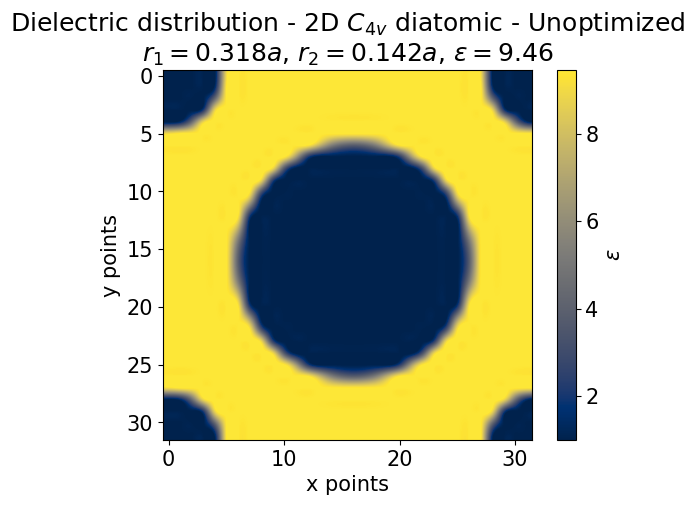

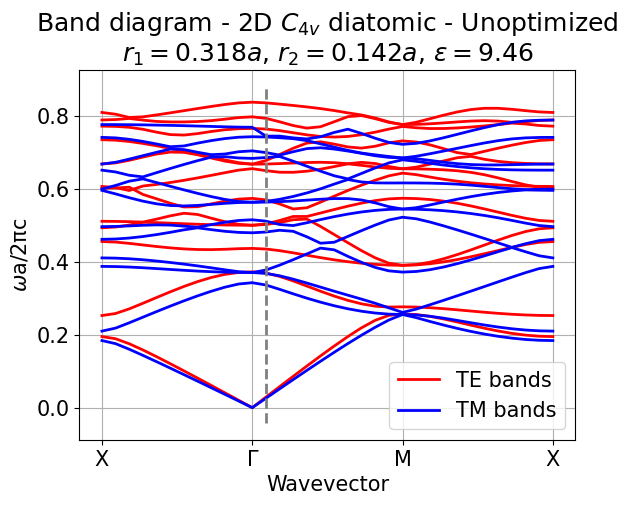

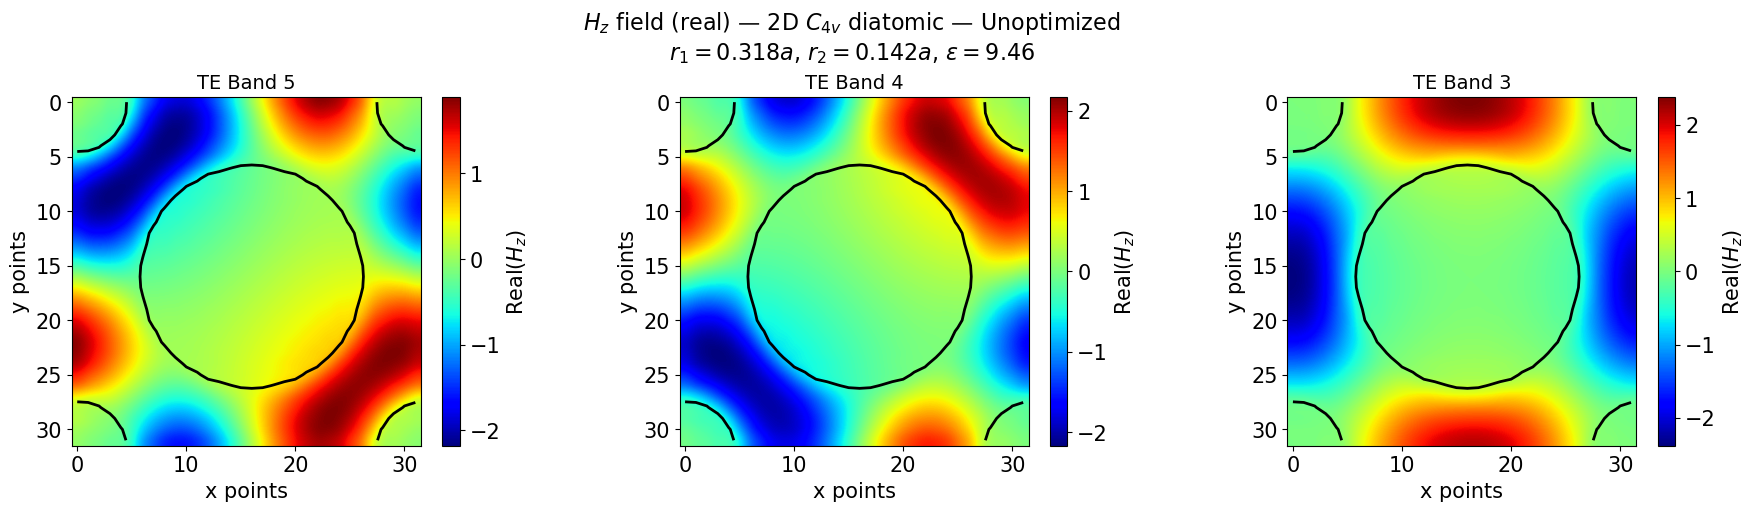

In [ ]:
r1 = 0.317578
r2 = 0.142463


run_if_needed(simulation_2D, dict(r1=r1, r2=r2))
print("2D simulation done")
viewer_2D = SimulationViewer(simulation_2D) 
opt = MPBDataOptions(rectify=True, periods= 1)
viewer_2D.figure()
viewer_2D.plot_epsilon_2d(conversion_options=opt)
eps_loaded = simulation_2D.load_and_convert_epsilon_data(options=opt)
print("Epsilon loaded max value: ", eps_loaded.max()) 
plt.xlabel("x points")
plt.ylabel("y points")
data_line = f"$r_1={r1:0.3f}a$, $r_2={r2:0.3f}a$, $\epsilon={eps_inp}$"
plt.title("Dielectric distribution - 2D $C_{4v}$ diatomic - Unoptimized\n" + data_line)
viewer_2D.show()


viewer_2D.plot_band_diagram("te", k_points_path=k_points, color = "red")
viewer_2D.plot_band_diagram("tm", k_points_path=k_points, color = "blue")
plt.ylabel("$\omega$a/2πc")
plt.title("Band diagram - 2D $C_{4v}$ diatomic - Unoptimized\n" + data_line)
ymin, ymax = plt.ylim()
k_idx_for_field_plot = 13
plt.vlines(k_idx_for_field_plot, ymin, ymax, colors="gray", linestyles="--", label=None)
viewer_2D.show()

df_te = simulation_2D.load_frequency_data("te")
# display(df_te)

# --- Field plots with improved layout ---


band_indices = [5, 4, 3]
polarization = "TE"
band_labels = [f"{polarization} Band {b}" for b in band_indices]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
fig.suptitle(f"$H_z$ field (real) — 2D $C_{{4v}}$ diatomic — Unoptimized\n{data_line}", fontsize=16)

for ax, b_idx, label in zip(axes, band_indices, band_labels):
    plt.sca(ax)
    cb = viewer_2D.plot_field_2d(k_idx_for_field_plot, b_idx, "h", "z", "te", False, np.real, overlay_epsilon_contour=True, conversion_options=opt)
    ax.set_title(label, fontsize=14)
    ax.set_xlabel("x points")
    ax.set_ylabel("y points")

plt.show()

### Optimization


#### Bands 4,5,6

Best point with filling_factor<0.3:  r1                0.215622
r2                0.289368
cost              0.000020
freq-dirac        0.553810
filling_factor    0.409120
Name: 236, dtype: float64
Best point with filling_factor>=0.3:  r1                0.372723
r2                0.297844
cost              0.000050
freq-dirac        0.744703
filling_factor    0.715131
Name: 72, dtype: float64


<Figure size 640x480 with 0 Axes>

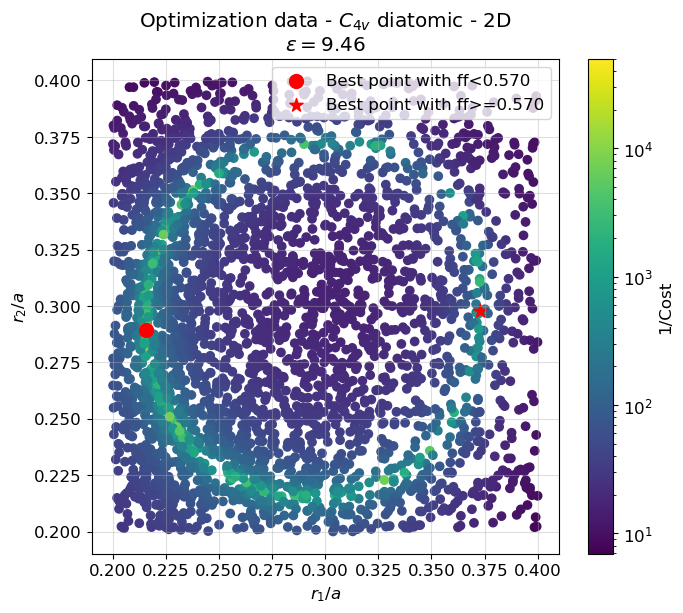

Weighted centroid: r1 = 0.2357, r2 = 0.2802
Best number of Fourier harmonics: 8


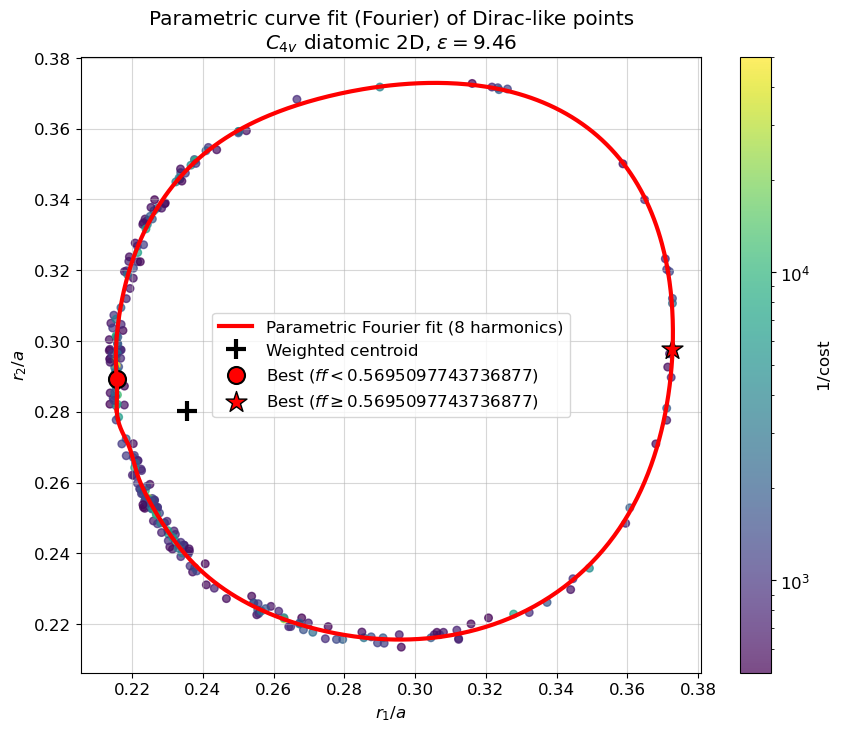


r1(θ) coefficients: a0=0.265217
  n=1: a_cos=0.072719, a_sin=0.003530
  n=2: a_cos=0.029602, a_sin=0.007554
  n=3: a_cos=0.005927, a_sin=0.003637
  n=4: a_cos=-0.000583, a_sin=0.000546
  n=5: a_cos=-0.000727, a_sin=-0.000082
  n=6: a_cos=-0.000808, a_sin=-0.000273
  n=7: a_cos=-0.000370, a_sin=-0.000265
  n=8: a_cos=-0.000197, a_sin=-0.000287

r2(θ) coefficients: c0=0.287235
  n=1: c_cos=0.003603, c_sin=0.060388
  n=2: c_cos=-0.006469, c_sin=0.029607
  n=3: c_cos=-0.003398, c_sin=0.006494
  n=4: c_cos=-0.000472, c_sin=0.000583
  n=5: c_cos=-0.000338, c_sin=0.000279
  n=6: c_cos=-0.000379, c_sin=-0.000350
  n=7: c_cos=0.000048, c_sin=-0.000569
  n=8: c_cos=0.000254, c_sin=-0.000307


,r1,r2,cost,freq-dirac,filling_factor
0,0.321720,0.371770,0.001227,0.767401,0.759375
1,0.223227,0.253016,0.001985,0.527515,0.357662
2,0.252320,0.359419,0.001614,0.679755,0.605850
3,0.360669,0.252862,0.000511,0.681931,0.609536
4,0.231875,0.246313,0.001351,0.530319,0.359511
...,...,...,...,...,...
258,0.238049,0.350186,0.000993,0.651179,0.563280
259,0.236138,0.241266,0.001684,0.529757,0.358049
260,0.215622,0.289368,0.000020,0.553810,0.409120
261,0.215622,0.289368,0.000020,0.553810,0.409120


,r1,r2,cost,freq-dirac,filling_factor
count,263.000000,263.000000,263.000000,263.000000,263.000000
mean,0.247062,0.276691,0.000928,0.577529,0.444203
std,0.043503,0.043799,0.000576,0.064242,0.106761
min,0.213572,0.213481,0.000020,0.523880,0.349725
25%,0.218911,0.241998,0.000454,0.531932,0.364577
50%,0.226849,0.267648,0.000906,0.553975,0.409120
75%,0.255720,0.304862,0.001362,0.597880,0.483980
max,0.372723,0.372787,0.001998,0.782383,0.789295


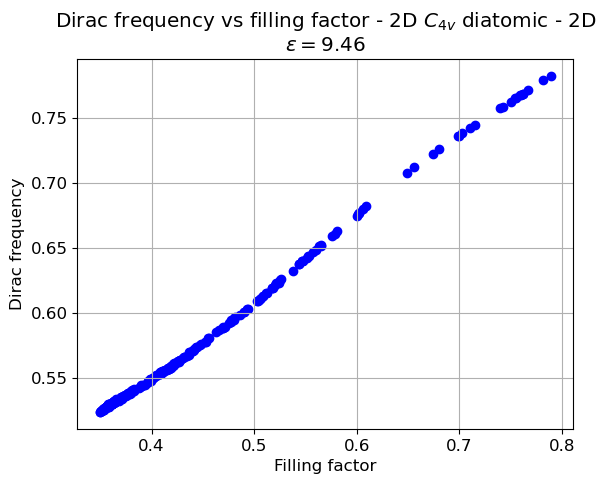

In [42]:
pop = 32
optimizer = MPIdeOptimizator(
        simulation_name=simulation_2D_opt_456.simulation_name,
        scheme_script=simulation_2D_opt_456.script, 
        maxiter=50,
        param_names=["r1", "r2"],
        param_bounds=[(0.2, 0.4), (0.2, 0.4)],
        polarization="te",
        de_options={
            "strategy": "rand1bin",
            "popsize": pop,
            "mutation": (0.8, 1.5),
            "recombination": 0.3,
            "tol": 1e-12,
            "init": "latinhypercube",
        },
        bands=[4,5,6],
        directory=simulation_2D_opt_456.directory,
    )
# optimizer.erease_data_file()
# optimizer.submit_lsf_job(lsf_config, conda_env_name="mpb-nzi-env")
plt.rcParams["font.size"] = 12
analyzer = OptimizationDataAnalyzer(optimizer.data_file)
plt.figure()
analyzer.plot_raw_data(plot_inverse_cost=True, points_only=True, use_logscale=True)
plt.grid(alpha=0.4) 
plt.xlabel("$r_1/a$")
plt.ylabel("$r_2/a$") 
plt.title("Optimization data - $C_{4v}$ diatomic - 2D" + "\n" +rf"$\varepsilon={eps_inp}$")   



df = analyzer.get_points_above_treshold(500)

# add a column to the dataframe with the filling factor of the unit cell, calculated as the area of the two circles divided by the area of the unit cell
df["filling_factor"] = (np.pi * df["r1"]**2 + np.pi * df["r2"]**2) / 1**2

# Threshold for filling factor
ff_min, ff_max = df["filling_factor"].min(), df["filling_factor"].max()
threshold_ff = (ff_min + ff_max) / 2

# find the combination of r1 and r2 that gives the minimum cost coming from the points with filling factor below the threshold
best_point_below_threshold = df.loc[df[df["filling_factor"] < threshold_ff]["cost"].idxmin()]
print("Best point with filling_factor<0.3: ", best_point_below_threshold)
r1_below_threshold, r2_below_threshold = best_point_below_threshold["r1"], best_point_below_threshold["r2"]

# find the point with the best cost among the points with filling factor above the threshold
best_point_above_threshold = df.loc[df[df["filling_factor"] >= threshold_ff]["cost"].idxmin()]
print("Best point with filling_factor>=0.3: ", best_point_above_threshold)
r1_above_threshold, r2_above_threshold = best_point_above_threshold["r1"], best_point_above_threshold["r2"]


# plot the point with the best cost
plt.scatter(best_point_below_threshold["r1"], best_point_below_threshold["r2"], color="red", label=rf"Best point with ff<{threshold_ff:0.3f}", marker="o", s=100)
plt.scatter(best_point_above_threshold["r1"], best_point_above_threshold["r2"], color="red", label=rf"Best point with ff>={threshold_ff:0.3f}", marker="*", s=100)
plt.legend()
plt.show()

# Fit a parametric closed curve r1(θ), r2(θ) weighted by 1/cost
# using Fourier series in the angular parameter θ
weights = 1.0 / df["cost"].values
r1_data = df["r1"].values
r2_data = df["r2"].values

# 1. Weighted centroid
r1_center = np.average(r1_data, weights=weights)
r2_center = np.average(r2_data, weights=weights)
print(f"Weighted centroid: r1 = {r1_center:.4f}, r2 = {r2_center:.4f}")

# 2. Angular coordinate θ for each point relative to the centroid
theta_data = np.arctan2(r2_data - r2_center, r1_data - r1_center)

# 3. Fit r1(θ) and r2(θ) as truncated Fourier series, weighted by 1/cost
#    r1(θ) = a0 + Σ [an*cos(nθ) + bn*sin(nθ)]
#    r2(θ) = c0 + Σ [cn*cos(nθ) + dn*sin(nθ)]
def build_fourier_design_matrix(theta, n_harmonics):
    """Build design matrix for Fourier fit: 1, cos(θ), sin(θ), cos(2θ), sin(2θ), ..."""
    N = len(theta)
    cols = [np.ones(N)]
    for n in range(1, n_harmonics + 1):
        cols.append(np.cos(n * theta))
        cols.append(np.sin(n * theta))
    return np.column_stack(cols)

# Choose number of harmonics (try 3-8, pick best via weighted BIC)
best_n_harm = 3
best_bic = np.inf
for n_harm in range(3, 9):
    F = build_fourier_design_matrix(theta_data, n_harm)
    W = np.diag(weights)
    # Weighted least squares for r1 and r2
    FtWF = F.T @ W @ F
    try:
        coeffs_r1 = np.linalg.solve(FtWF, F.T @ W @ r1_data)
        coeffs_r2 = np.linalg.solve(FtWF, F.T @ W @ r2_data)
    except np.linalg.LinAlgError:
        continue
    r1_pred = F @ coeffs_r1
    r2_pred = F @ coeffs_r2
    n_params = 2 * (2 * n_harm + 1)
    n_pts = len(r1_data)
    residuals = weights * ((r1_data - r1_pred)**2 + (r2_data - r2_pred)**2)
    bic = n_pts * np.log(np.sum(residuals) / n_pts) + n_params * np.log(n_pts)
    if bic < best_bic:
        best_bic = bic
        best_n_harm = n_harm
        best_coeffs_r1 = coeffs_r1
        best_coeffs_r2 = coeffs_r2

print(f"Best number of Fourier harmonics: {best_n_harm}")

# Evaluate the parametric curve on a fine grid
theta_fine = np.linspace(-np.pi, np.pi, 1000)
F_fine = build_fourier_design_matrix(theta_fine, best_n_harm)
r1_curve = F_fine @ best_coeffs_r1
r2_curve = F_fine @ best_coeffs_r2

# Plot the parametric curve on top of the data
plt.figure(figsize=(10, 8))
sc = plt.scatter(r1_data, r2_data, c=1/df["cost"], cmap="viridis",
                 norm=colors.LogNorm(vmin=(1/df["cost"]).min(), vmax=(1/df["cost"]).max()),
                 s=30, alpha=0.7)
plt.colorbar(sc, label="$1/\\mathrm{cost}$")
plt.plot(r1_curve, r2_curve, "r-", linewidth=3, label=f"Parametric Fourier fit ({best_n_harm} harmonics)")
plt.plot(r1_center, r2_center, "k+", markersize=15, markeredgewidth=3, label="Weighted centroid")

# Mark best points
plt.scatter(best_point_below_threshold["r1"], best_point_below_threshold["r2"],
            color="red", marker="o", s=150, edgecolors="black", linewidths=1.5,
            label=rf"Best ($ff<{threshold_ff}$)")
plt.scatter(best_point_above_threshold["r1"], best_point_above_threshold["r2"],
            color="red", marker="*", s=250, edgecolors="black", linewidths=1.0,
            label=rf"Best ($ff\geq{threshold_ff}$)")

plt.xlabel("$r_1/a$")
plt.ylabel("$r_2/a$")
plt.title("Parametric curve fit (Fourier) of Dirac-like points\n" + rf"$C_{{4v}}$ diatomic 2D, $\varepsilon={eps_inp}$")
plt.legend(loc="best")
plt.grid(True, alpha=0.5)
plt.axis("equal")
plt.show()

# Print Fourier coefficients
print(f"\nr1(θ) coefficients: a0={best_coeffs_r1[0]:.6f}")
for n in range(1, best_n_harm + 1):
    print(f"  n={n}: a_cos={best_coeffs_r1[2*n-1]:.6f}, a_sin={best_coeffs_r1[2*n]:.6f}")
print(f"\nr2(θ) coefficients: c0={best_coeffs_r2[0]:.6f}")
for n in range(1, best_n_harm + 1):
    print(f"  n={n}: c_cos={best_coeffs_r2[2*n-1]:.6f}, c_sin={best_coeffs_r2[2*n]:.6f}")

# dosplay the hole dataframe
display(df, df.describe())   

# In a new figure plot the freq-dirac against the filling factor
plt.figure()
plt.scatter(df["filling_factor"], df["freq-dirac"], color="blue")
plt.xlabel("Filling factor")
plt.ylabel("Dirac frequency")
plt.title("Dirac frequency vs filling factor - 2D $C_{4v}$ diatomic - 2D" + "\n" +rf"$\varepsilon={eps_inp}$")
plt.grid()
plt.show()

### Sweep

In [43]:
# # Sweep 2D 
# # Instantiate the new sweeper
# r1 = 0.19

# values = np.linspace(0.1, 0.3, 20, endpoint=True)
# sweeper = LSFSweeper(simulation_2D_sweep.simulation_name + "_r2_big", directory=simulation_2D_sweep.directory + "_r2_big",
#                      scheme_script=simulation_2D_sweep.script, 
#                         param_name="r2", param_values=values,
#                         polarization="te",
#                         bands=[2,3,4,5,6,7],
#                         others_command_line_params={"r1": r1},
#                        )

# #Run the sweeper
# # sweeper.submit_lsf_job(lsf_config)
# df = sweeper.load_results()
# #display(df)
# print(r1,r2)
# plt.figure(figsize=(10, 6))
# plt.rcParams["font.size"] = 20
# plt.rcParams["lines.linewidth"] = 4

# plt.plot(df["r2"], df["band_2"], label="band 2")
# plt.plot(df["r2"], df["band_3"], label="band 3")
# plt.plot(df["r2"], df["band_4"], label="band 4", marker="o")
# plt.plot(df["r2"], df["band_5"], label="band 5")
# plt.plot(df["r2"], df["band_6"], label="band 6")
# plt.plot(df["r2"], df["band_7"], label="band 7")

# plt.grid()
# plt.xlabel("$r_2/a$")
# plt.ylabel("$\omega_Da/2\pi c$")
# ylim = plt.ylim()
# #plt.plot([r2, r2], ylim, "r--", label = f"$r_2/a = {round(r2,5):0.5f}$")
# idx_freq_dirac = np.argmin(np.abs(df["band_6"] - df["band_4"]))

# #plt.plot(df["r2"][idx_freq_dirac], df["band_6"][idx_freq_dirac], "go", label = f"$r_2/a ={round(df['r2'][idx_freq_dirac],5):0.5f}$, $\omega_Da/2\pi c = {df['band_4'][idx_freq_dirac]:0.4f}$, \n $\lambda_0 = 1550nm $, a = {df['band_4'][idx_freq_dirac]*1550:0.0f}nm") 
# plt.title("Band diagram - 2D $C_{4v}$ diatomic - Unoptimized\n" + f"$T = {T}K$, $\epsilon_{{InP}}(T)={eps}$")
# plt.legend()
# plt.title(f"Sweep of $r_2$ at $r_1/a = {r1:0.4f}$, $T={T}K$")
# plt.savefig(f"sweep_r2_h_0.35_r1_{r1:0.4f}.png")
# plt.show()

# c0 = 299792458



In [44]:
# # Sweep 2D 
# # Instantiate the new sweeper
# r1 = 0.24
# r2 = analyzer.compute_param2_from_param1_on_ellipse(r1, a, "lower") 
# print("r1: ", r1)
# print("r2: ", r2)

# values = np.linspace(0.23, 0.24, 64, endpoint=True)
# sweeper = LSFSweeper(simulation_2D_sweep.simulation_name + "_r2", directory=simulation_2D_sweep.directory + "_r2",
#                      scheme_script=simulation_2D_sweep.script, 
#                         param_name="r2", param_values=values,
#                         polarization="te",
#                         bands=[4,5,6],
#                         others_command_line_params={"r1": r1},
#                        )

# #Run the sweeper
# # sweeper.submit_lsf_job(lsf_config)
# df = sweeper.load_results()
# #display(df)
# print(r1,r2)
# plt.rcParams["lines.linewidth"] = 3
# plt.figure(figsize=(12, 8))
# ms = 10

# plt.plot(df["r2"], df["band_4"], "o-",  label="band 4", markersize=ms)
# plt.plot(df["r2"], df["band_5"], "x-",label="band 5", markersize=ms)
# plt.plot(df["r2"], df["band_6"], ".-", label="band 6", markersize=ms)

# plt.grid()
# plt.xlabel("$r_2/a$")
# plt.ylabel("$\omega_Da/2\pi c$")
# ylim = plt.ylim()
# plt.plot([r2, r2], ylim, "r--", label = f"$r_2/a = {round(r2,5):0.4f}$")
# idx_freq_dirac = np.argmin(np.abs(df["band_6"] - df["band_4"]))

# plt.scatter(df["r2"][idx_freq_dirac], df["band_6"][idx_freq_dirac], 100, "k", label = f"$r_2/a ={round(df['r2'][idx_freq_dirac],5):0.4f}$, $\omega_Da/2\pi c = {df['band_4'][idx_freq_dirac]:0.4f}$, \n $\lambda_0 = 1550nm $, a = {df['band_4'][idx_freq_dirac]*1550:0.0f}nm", zorder = 5) 
# plt.title("Band diagram - 2D $C_{4v}$ diatomic - Unoptimized\n" + f"$T = {T}K$, $\epsilon_{{InP}}(T)={eps}$")
# plt.legend()
# plt.title(f"Sweep of $r_2$ at $r_1/a = {r1:0.4f}$, $T={T}K$, 2D diatomic $C_{{4v}}$ ")
# plt.savefig(f"sweep_r2_h_0.35_r1_{r1:0.4f}.png")
# plt.show()

# c0 = 299792458



### Optimized

#### Above FF threshold

r2:  0.29784408447837607 r1:  0.37272276943706906 filling factor:  0.7151312962493602
2D simulation done


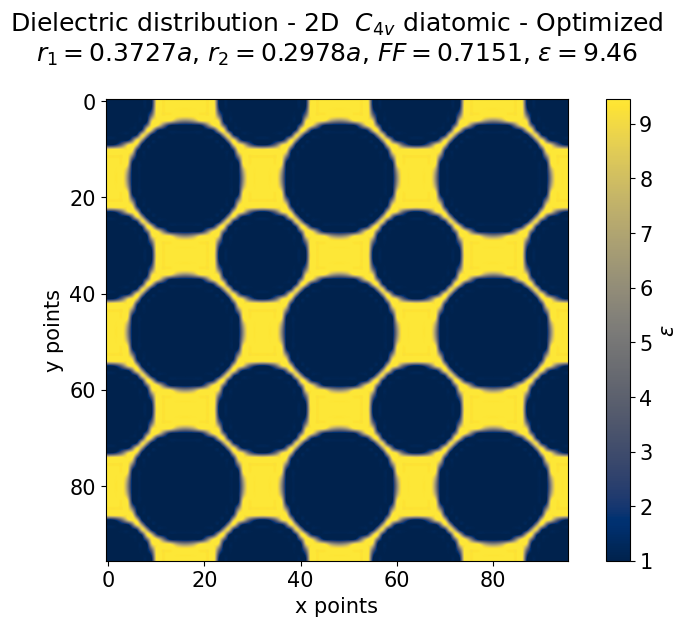

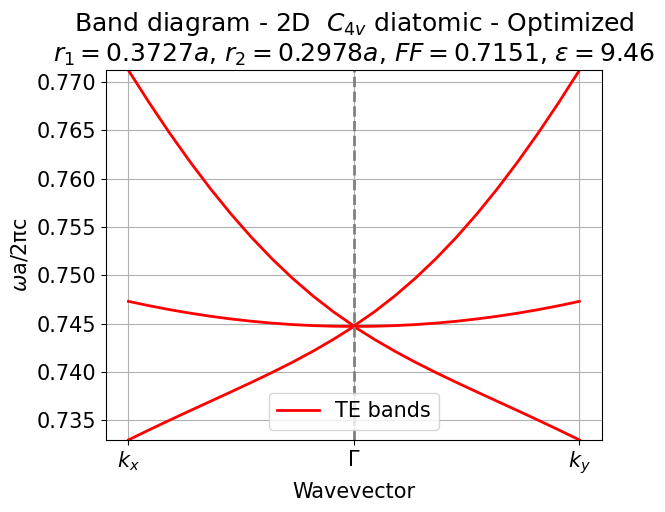

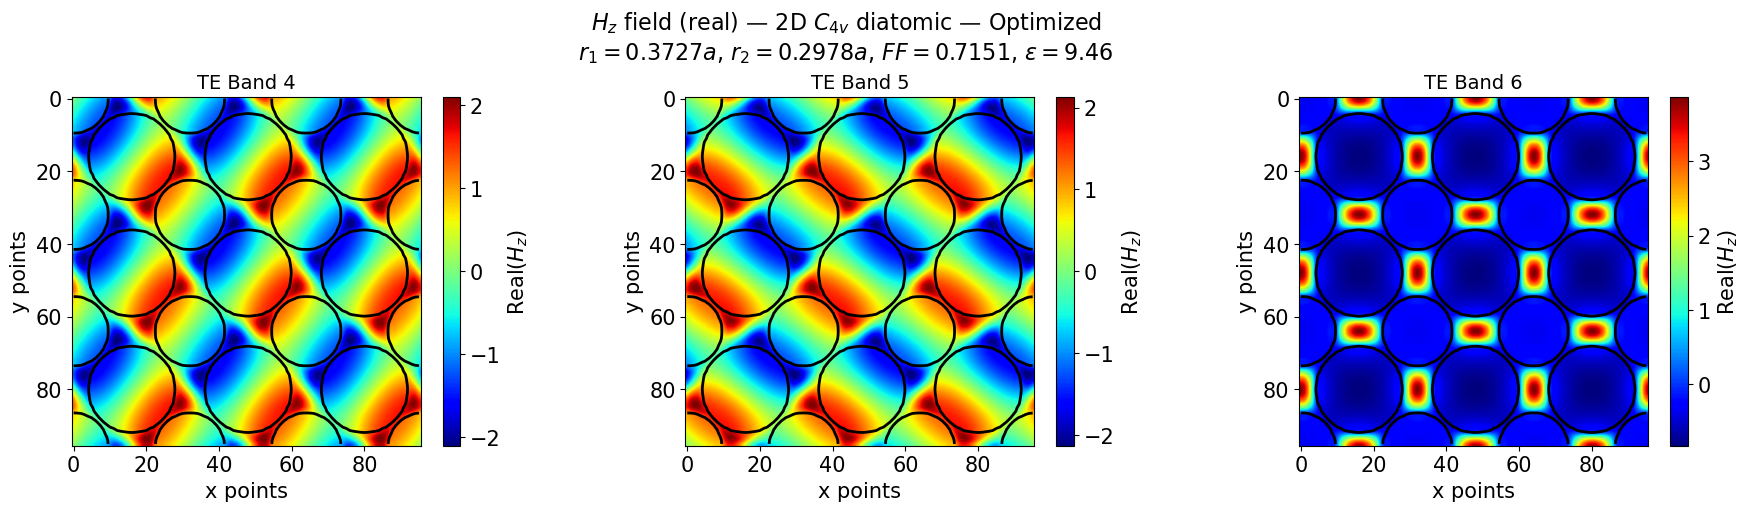

In [ ]:
r1 = r1_above_threshold
r2 = r2_above_threshold
print("r2: ", r2, "r1: ", r1, "filling factor: ", (np.pi*r1**2 + np.pi*r2**2))
plt.rcParams["font.size"] = 15

# Parameter-specific simulation for caching (avoids overwriting below-threshold results)
sim_2D_above = get_param_sim(simulation_2D_optimized, r1, r2)
run_if_needed(sim_2D_above, dict(r1=r1, r2=r2))
print("2D simulation done")
viewer_2D = SimulationViewer(sim_2D_above) 
opt = MPBDataOptions(rectify=True, periods= 3, transpose=False)
plt.figure(figsize=(10, 6))
viewer_2D.plot_epsilon_2d(conversion_options=opt)
plt.xlabel("x points")
plt.ylabel("y points")
data_line = f"$r_1={r1:.4f}a$, $r_2={r2:.4f}a$, $FF = {np.pi*r1**2 + np.pi*r2**2:.4f}$, $\epsilon={eps_inp}$"
plt.title("Dielectric distribution - 2D  $C_{4v}$ diatomic - Optimized\n" + data_line+"\n")
viewer_2D.show()

#viewer_2D.plot_band_diagram("tm", k_points_path=k_points_around_gamma, color = "blue")
viewer_2D.plot_band_diagram("te", k_points_path=k_points_around_gamma, color = "red")
plt.ylabel("$\omega$a/2πc")
plt.title("Band diagram - 2D  $C_{4v}$ diatomic - Optimized\n" + data_line)

df = sim_2D_above.load_frequency_data("te")

max_freq = df["te band 6"].max()
min_freq = df["te band 4"].min()

len_k_points = len(k_points["k_points_values"])

plt.ylim(min_freq, max_freq)


ax = plt.gca()
k_idx_for_field_plot = 12
plt.vlines(k_idx_for_field_plot, min_freq, max_freq, color="gray", linestyle="--", label=None)
viewer_2D.show()

# --- Field plots ---


band_indices = [4,5,6]
polarization = "TE"
band_labels = [f"{polarization} Band {b}" for b in band_indices]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
fig.suptitle(f"$H_z$ field (real) — 2D $C_{{4v}}$ diatomic — Optimized\n{data_line}", fontsize=16)

for ax, b_idx, label in zip(axes, band_indices, band_labels):
    plt.sca(ax)
    cb = viewer_2D.plot_field_2d(k_idx_for_field_plot, b_idx, "h", "z", polarization.lower(), False, np.real, overlay_epsilon_contour=True, conversion_options=opt)
    ax.set_title(label, fontsize=14)
    ax.set_xlabel("x points")
    ax.set_ylabel("y points")

plt.show()

#### Below FF Threshold

r2:  0.2893684110882849 r1:  0.21562231086468173 filling factor:  0.40912036958598136
2D simulation done


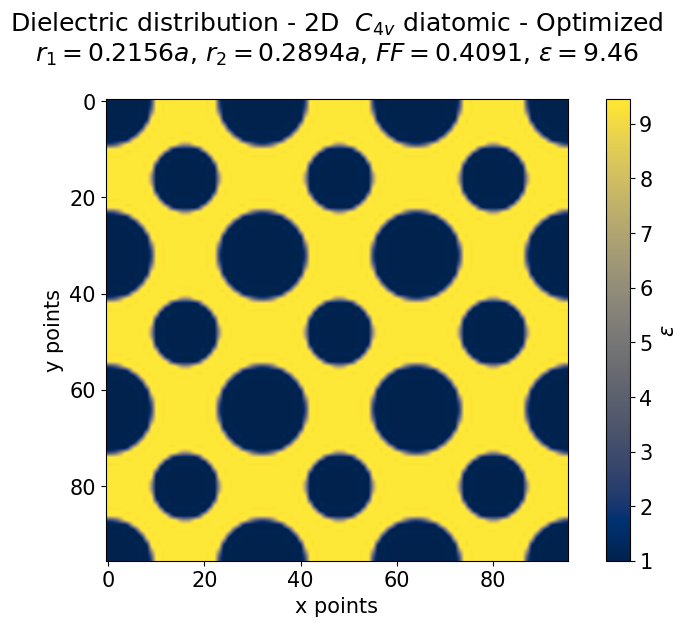

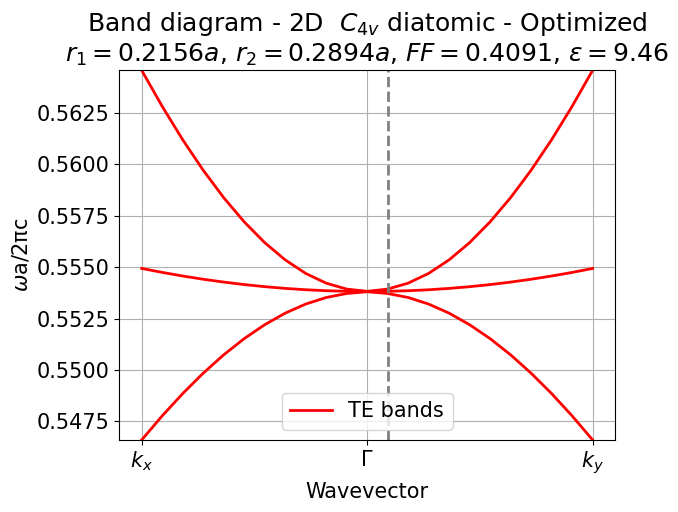

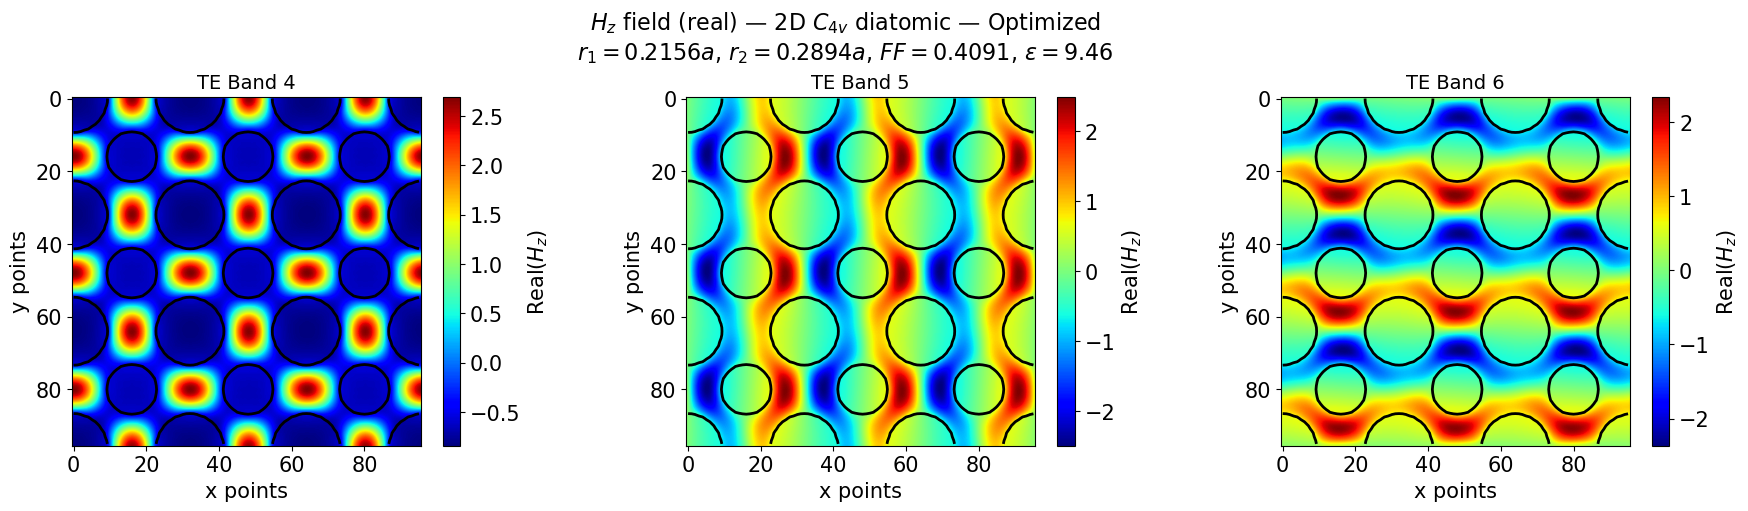

In [ ]:
r1 = r1_below_threshold
r2 = r2_below_threshold
print("r2: ", r2, "r1: ", r1, "filling factor: ", (np.pi*r1**2 + np.pi*r2**2))
plt.rcParams["font.size"] = 15

# Parameter-specific simulation for caching
sim_2D_below = get_param_sim(simulation_2D_optimized, r1, r2)
run_if_needed(sim_2D_below, dict(r1=r1, r2=r2))
print("2D simulation done")
viewer_2D = SimulationViewer(sim_2D_below) 
opt = MPBDataOptions(rectify=True, periods= 3, transpose=False)
plt.figure(figsize=(10, 6))
viewer_2D.plot_epsilon_2d(conversion_options=opt)
plt.xlabel("x points")
plt.ylabel("y points")
data_line = f"$r_1={r1:.4f}a$, $r_2={r2:.4f}a$, $FF = {np.pi*r1**2 + np.pi*r2**2:.4f}$, $\epsilon={eps_inp}$"
plt.title("Dielectric distribution - 2D  $C_{4v}$ diatomic - Optimized\n" + data_line+"\n")
viewer_2D.show()

viewer_2D.plot_band_diagram("te", k_points_path=k_points_around_gamma, color = "red")
# viewer_2D.plot_band_diagram("tm", k_points_path=k_points_around_gamma, color = "blue")
plt.ylabel("$\omega$a/2πc")
plt.title("Band diagram - 2D  $C_{4v}$ diatomic - Optimized\n" + data_line)

df = sim_2D_below.load_frequency_data("te")

max_freq = df["te band 6"].max()
min_freq = df["te band 4"].min()

plt.ylim(min_freq, max_freq)


ax = plt.gca()

k_idx_for_field_plot = 13
plt.vlines(k_idx_for_field_plot, min_freq, max_freq, colors="gray", linestyles="--", label=None)


# plt.title("")
viewer_2D.show()

# --- Field plots with improved layout ---


band_indices = [4,5,6]
polarization = "TE"
band_labels = [f"{polarization} Band {b}" for b in band_indices]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
fig.suptitle(f"$H_z$ field (real) — 2D $C_{{4v}}$ diatomic — Optimized\n{data_line}", fontsize=16)

for ax, b_idx, label in zip(axes, band_indices, band_labels):
    plt.sca(ax)
    cb = viewer_2D.plot_field_2d(k_idx_for_field_plot, b_idx, "h", "z", polarization.lower(), False, np.real, overlay_epsilon_contour=True, conversion_options=opt)
    ax.set_title(label, fontsize=14)
    ax.set_xlabel("x points")
    ax.set_ylabel("y points")

plt.show()

# Store for quiver plots in next cell
sim_for_quiver = sim_2D_below

Saving figures to: /zhome/2f/7/202918/phc_nzi/notebooks/phd/figures/r1_0.2156_r2_0.2894_eps_9.46
Saved → /zhome/2f/7/202918/phc_nzi/notebooks/phd/figures/r1_0.2156_r2_0.2894_eps_9.46/mode_profile_TE_band_4_r1_0.2156_r2_0.2894_eps_9.46.png
Saved → /zhome/2f/7/202918/phc_nzi/notebooks/phd/figures/r1_0.2156_r2_0.2894_eps_9.46/mode_profile_TE_band_5_r1_0.2156_r2_0.2894_eps_9.46.png
Saved → /zhome/2f/7/202918/phc_nzi/notebooks/phd/figures/r1_0.2156_r2_0.2894_eps_9.46/mode_profile_TE_band_6_r1_0.2156_r2_0.2894_eps_9.46.png
Saved → /zhome/2f/7/202918/phc_nzi/notebooks/phd/figures/r1_0.2156_r2_0.2894_eps_9.46/mode_profiles_combined_r1_0.2156_r2_0.2894_eps_9.46.png


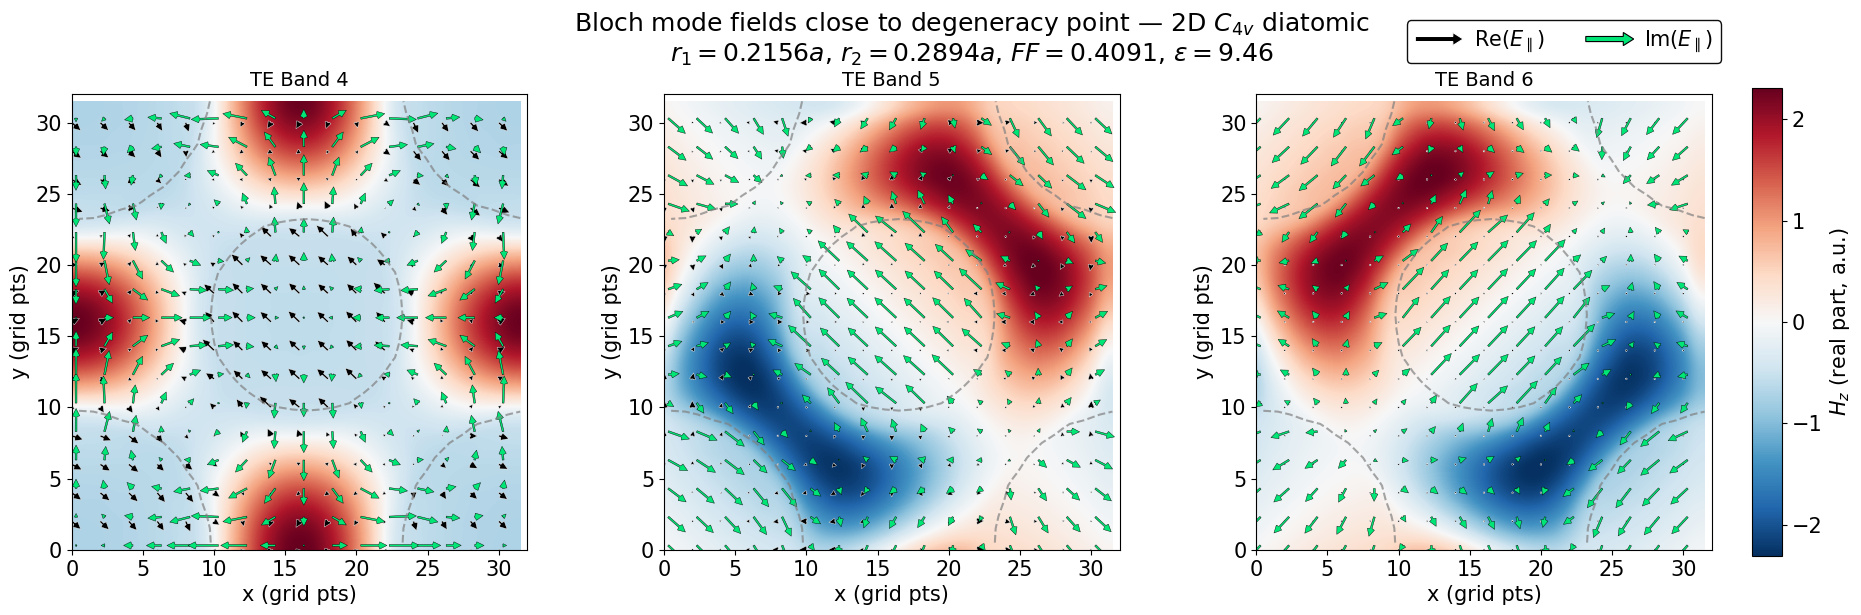

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow
from matplotlib.legend_handler import HandlerPatch
import os

fontsize_content = 15
plt.rcParams["font.size"] = fontsize_content
fontsize_title = 18


# --- Arrow colors ---
COLOR_RE = 'black'
COLOR_IM = '#00E676'        # bright green
EDGE_RE  = 'white'
EDGE_IM  = 'black'

# Build a parameter-stamped subfolder: figures/r1_XXXX_r2_XXXX_eps_XX
param_tag = f"r1_{r1:.4f}_r2_{r2:.4f}_eps_{eps_inp:.2f}"
SAVE_DIR = os.path.join(os.path.dirname(os.path.abspath(".")), "phd", "figures", param_tag)
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Saving figures to: {SAVE_DIR}")


class ArrowHandler(HandlerPatch):
    """Custom legend handler that draws an arrow instead of a rectangle."""
    def create_artists(self, legend, orig_handle, xdescent, ydescent,
                       width, height, fontsize, trans):
        arrow = FancyArrow(
            xdescent, ydescent + height / 2,
            width * 0.9, 0,
            width=height * 0.35,
            head_width=height * 0.9,
            head_length=width * 0.25,
            fc=orig_handle.get_facecolor(),
            ec=orig_handle.get_edgecolor(),
            linewidth=0.8,
            transform=trans
        )
        return [arrow]


def _add_arrow_legend(fig_or_ax, is_figure=False, **kwargs):
    """Add arrow-style legend for Re/Im E_parallel."""
    arrow_re = FancyArrow(0, 0.5, 0.5, 0, width=0.08,
                          head_width=0.25, head_length=0.12,
                          fc=COLOR_RE, ec=EDGE_RE)
    arrow_im = FancyArrow(0, 0.5, 0.5, 0, width=0.08,
                          head_width=0.25, head_length=0.12,
                          fc=COLOR_IM, ec=EDGE_IM)
    target = fig_or_ax.legend if is_figure else fig_or_ax.legend
    return target(
        [arrow_re, arrow_im],
        [r'$\mathrm{Re}(E_{\parallel})$', r'$\mathrm{Im}(E_{\parallel})$'],
        handler_map={FancyArrow: ArrowHandler()},
        ncol=2, fontsize=fontsize_content,
        framealpha=0.95, facecolor='white', edgecolor='black',
        **kwargs
    )


def plot_field_quiver_on_ax(ax, k_idx, b_idx, sim=None):
    """Plot H_z background with E-field quiver arrows on a given axes."""
    if sim is None:
        sim = sim_for_quiver
    opt = MPBDataOptions(rectify=True, periods=1, transpose=False)

    H_field = sim.load_and_convert_field_data(
        k_idx, b_idx, "z", "te", "h", conversion_options=opt)
    E_field_x = sim.load_and_convert_field_data(
        k_idx, b_idx, "x", "te", "e", conversion_options=opt)
    E_field_y = sim.load_and_convert_field_data(
        k_idx, b_idx, "y", "te", "e", conversion_options=opt)

    H_real = np.real(H_field)
    vmax_h = np.max(np.abs(H_real))
    im = ax.imshow(H_real, interpolation='spline36', cmap="RdBu_r",
                   vmin=-vmax_h, vmax=vmax_h, origin='lower')

    step = 2
    ny, nx = H_field.shape
    x = np.arange(nx)
    y = np.arange(ny)
    X, Y = np.meshgrid(x, y)
    X_sub = X[::step, ::step]
    Y_sub = Y[::step, ::step]

    Ex_r = np.real(E_field_x)[::step, ::step]
    Ey_r = np.real(E_field_y)[::step, ::step]
    Ex_i = np.imag(E_field_x)[::step, ::step]
    Ey_i = np.imag(E_field_y)[::step, ::step]

    mag_real = np.sqrt(Ex_r**2 + Ey_r**2)
    mag_imag = np.sqrt(Ex_i**2 + Ey_i**2)
    max_mag = max(mag_real.max(), mag_imag.max())
    arrow_scale = max_mag * 15

    ax.quiver(X_sub, Y_sub, Ex_r, Ey_r,
              color=COLOR_RE, edgecolor=EDGE_RE, linewidth=0.3,
              scale=arrow_scale, width=0.004, headwidth=4, headlength=4)

    offset = 0.3
    ax.quiver(X_sub + offset, Y_sub + offset, Ex_i, Ey_i,
              color=COLOR_IM, edgecolor=EDGE_IM, linewidth=0.3,
              scale=arrow_scale, width=0.004, headwidth=4, headlength=4)

    try:
        eps_data = sim.load_and_convert_epsilon_data(options=opt)
        ax.contour(eps_data, levels=[eps_data.max() * 0.5],
                   colors='gray', linewidths=1.5, linestyles='--',
                   alpha=0.7, origin='lower')
    except Exception:
        pass

    ax.set_xlabel("x (grid pts)")
    ax.set_ylabel("y (grid pts)")
    ax.set_xlim(0, nx)
    ax.set_ylim(0, ny)
    ax.set_aspect('equal')
    return im


# ============================================================
# 1) Save each band as a separate figure (no title, with cbar)
# ============================================================
band_indices = [4, 5, 6]
for b_idx in band_indices:
    fig_s, ax_s = plt.subplots(figsize=(7, 6))
    im_s = plot_field_quiver_on_ax(ax_s, 12, b_idx)
    plt.colorbar(im_s, ax=ax_s, label=r"$H_{z}$ (real part, a.u.)",
                 shrink=0.82, pad=0.02, aspect=25)
    _add_arrow_legend(ax_s, loc='upper right')
    fig_s.tight_layout()
    fname = os.path.join(SAVE_DIR, f"mode_profile_TE_band_{b_idx}_{param_tag}.png")
    fig_s.savefig(fname, dpi=200, bbox_inches='tight')
    plt.close(fig_s)
    print(f"Saved → {fname}")


# ============================================================
# 2) Combined figure with 3 subplots (with title)
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6.5))

for ax, b_idx in zip(axes, band_indices):
    im = plot_field_quiver_on_ax(ax, 12, b_idx)
    ax.set_title(f"TE Band {b_idx}", fontsize=14)

# Layout: leave room for suptitle on top, legend at bottom, colorbar right
fig.subplots_adjust(left=0.05, right=0.87, bottom=0.13, top=0.85, wspace=0.30)

# Shared colorbar
cbar_ax = fig.add_axes([0.89, 0.13, 0.015, 0.72])
fig.colorbar(im, cax=cbar_ax, label=r"$H_{z}$ (real part, a.u.)")

# Arrow legend — top right
_add_arrow_legend(fig, is_figure=True,
                  loc='upper right',
                  bbox_to_anchor=(0.88, 0.97))

fig.suptitle(
    r"Bloch mode fields close to degeneracy point — 2D $C_{4v}$ diatomic"
    + "\n" + data_line,
    fontsize=fontsize_title, y=0.97
)

fname_combined = os.path.join(SAVE_DIR, f"mode_profiles_combined_{param_tag}.png")

fig.savefig(fname_combined, dpi=200, bbox_inches='tight')
print(f"Saved → {fname_combined}")
plt.show()

### Band Linearity Analysis
Evaluate the linearity of the top Dirac-cone band (band 6) for points along the optimization ellipse.

COMMANDS ['(define-param h 1e+20)', '(define-param r1 0.1)', '(define-param r2 0.2)']
Sampling 50 points along the Dirac ellipse
  r1 range: [0.2153, 0.3733]
  r2 range: [0.2149, 0.3752]


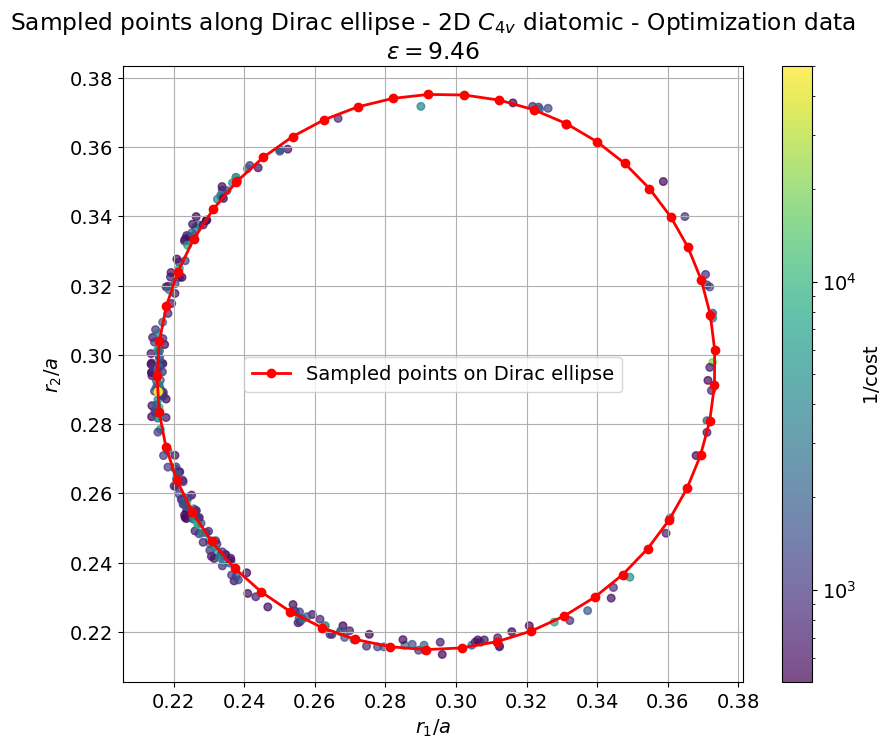

Running 50 simulations with 8 workers...
  [4/50] r1=0.3023, r2=0.3751 done
  [6/50] r1=0.2821, r2=0.3741 done
  [7/50] r1=0.2722, r2=0.3716 done
  [8/50] r1=0.2627, r2=0.3679 done
  [5/50] r1=0.2922, r2=0.3752 done
  [2/50] r1=0.3220, r2=0.3708 done
  [1/50] r1=0.3312, r2=0.3668 done
  [3/50] r1=0.3123, r2=0.3736 done
  [9/50] r1=0.2537, r2=0.3630 done
  [10/50] r1=0.2453, r2=0.3570 done
  [11/50] r1=0.2378, r2=0.3500 done
  [12/50] r1=0.2312, r2=0.3421 done
  [13/50] r1=0.2256, r2=0.3334 done
  [14/50] r1=0.2212, r2=0.3240 done
  [15/50] r1=0.2179, r2=0.3142 done
  [16/50] r1=0.2160, r2=0.3041 done
  [17/50] r1=0.2153, r2=0.2938 done
  [18/50] r1=0.2159, r2=0.2836 done
  [19/50] r1=0.2178, r2=0.2735 done
  [20/50] r1=0.2209, r2=0.2638 done
  [21/50] r1=0.2253, r2=0.2546 done
  [22/50] r1=0.2308, r2=0.2461 done
  [24/50] r1=0.2448, r2=0.2316 done
  [23/50] r1=0.2373, r2=0.2384 done
  [25/50] r1=0.2530, r2=0.2258 done
  [31/50] r1=0.3116, r2=0.2172 done
  [26/50] r1=0.2620, r2=0.2212 d

In [ ]:
import pandas as pd
from scipy.stats import linregress

distance = 0.05
k_points_around_gamma = lattice_2D.get_k_points_around_gamma(distance = distance)
# Create a lean configuration: only frequencies, no field output
config_linearity = dict(
    resolution=RESOLUTION,
    num_bands=8,
    k_points=k_points_around_gamma["k_points_values"],
    k_points_interpolation_factor=60,
)
mpb_config_lin = MPBSchemeConfigurator(photonic_crystal_2D, ["te"], **config_linearity)
script_lin = mpb_config_lin.get_scheme_config(join_newline=True)

# Sample points along the Dirac-like ellipse from optimization data
threshold_lin = 500
n_samples = 50
r1_ell, r2_ell, f_ell, _ = analyzer.compute_freq_dirac_along_ellipse(
    threshold=threshold_lin, n_points=n_samples)
print(f"Sampling {n_samples} points along the Dirac ellipse")
print(f"  r1 range: [{r1_ell.min():.4f}, {r1_ell.max():.4f}]")
print(f"  r2 range: [{r2_ell.min():.4f}, {r2_ell.max():.4f}]")

# Plot the sampled points on top of the cost landscape
p1 = analyzer.param1_name
p2 = analyzer.param2_name
plt.figure(figsize=(10, 8))
df = analyzer.get_points_above_treshold(threshold_lin)
sc = plt.scatter(df[p1], df[p2], c=1/df["cost"], cmap="viridis", norm=colors.LogNorm(vmin=(1/df["cost"]).min(), vmax=(1/df["cost"]).max()), s=30, alpha=0.7)
plt.colorbar(sc, label="$1/\\mathrm{cost}$")
plt.plot(r1_ell, r2_ell, "ro-", label="Sampled points on Dirac ellipse")
plt.xlabel("$r_1/a$")
plt.ylabel("$r_2/a$")
plt.title("Sampled points along Dirac ellipse - 2D $C_{4v}$ diatomic - Optimization data\n" + rf"$\varepsilon={eps_inp}$")  
plt.legend()
plt.grid(True)
plt.show()

# Create a unique Simulation object for each ellipse point
sims_lin = []
for i, (r1_i, r2_i) in enumerate(zip(r1_ell, r2_ell)):
    sim_name = f"{name_2D_optimized}_lin_{i:03d}"
    sim = Simulation(
        simulation_name=sim_name,
        script=script_lin,
        directory=os.path.join(data_rooth, sim_name)
    )
    sims_lin.append({'r1': r1_i, 'r2': r2_i, 'sim': sim, 'f_dirac_approx': f_ell[i]})

# Auto-detect which simulations need to run
sims_to_run = [(j, e) for j, e in enumerate(sims_lin) if not simulation_has_results(e['sim'])]
n_cached = len(sims_lin) - len(sims_to_run)
print(f"{n_cached}/{len(sims_lin)} linearity simulations already cached, {len(sims_to_run)} need to run")

if sims_to_run:
    from concurrent.futures import ThreadPoolExecutor, as_completed
    N_WORKERS = 8

    def run_lin_entry(args):
        j, entry = args
        entry['sim'].run_hpc(
            mpb_command_line_params=dict(r1=entry['r1'], r2=entry['r2']),
            mpi=True, load_epsilon=False)
        return j

    print(f"Running {len(sims_to_run)} simulations with {N_WORKERS} workers...")
    with ThreadPoolExecutor(max_workers=N_WORKERS) as pool:
        futures = {pool.submit(run_lin_entry, (j, sims_lin[j])): j for j, _ in sims_to_run}
        for fut in as_completed(futures):
            j = fut.result()
            print(f"  [{j+1}/{len(sims_lin)}] r1={sims_lin[j]['r1']:.4f}, r2={sims_lin[j]['r2']:.4f} done")
    print(f"\nAll {len(sims_to_run)} simulations completed.")
else:
    print("All linearity simulations cached — no simulations needed.")

COMMANDS ['(define-param h 1e+20)', '(define-param r1 0.1)', '(define-param r2 0.2)']
Sweeping r2 for 50 points × 30 r2 values = 1500 Γ-only simulations
Running 20 sweepers in parallel...
step 1/30: r2 = 0.3617967086881435
step 1/30: r2 = 0.36581012676027785
step 1/30: r2 = 0.36858019926184565
step 1/30: r2 = 0.370061441678954
step 1/30: r2 = 0.3702295320520651
step 1/30: r2 = 0.36908171034189957
step 1/30: r2 = 0.3666368237492051
step 1/30: r2 = 0.3629350172442412
step 1/30: r2 = 0.3580370743874774
step 1/30: r2 = 0.35202341926521086
step 1/30: r2 = 0.3449927959282927
step 1/30: r2 = 0.337060647017543
step 1/30: r2 = 0.3283572181987803
step 1/30: r2 = 0.3190254195325892
step 1/30: r2 = 0.3092184788950773
step 1/30: r2 = 0.29909742598038486
step 1/30: r2 = 0.2888284481975596
step 1/30: r2 = 0.27858016187789425
step 1/30: r2 = 0.2685208435994286
step 1/30: r2 = 0.25881566709019016
step 2/30: r2 = 0.36615495434648476
step 2/30: r2 = 0.366981651335412
step 2/30: r2 = 0.3453376235144996
st

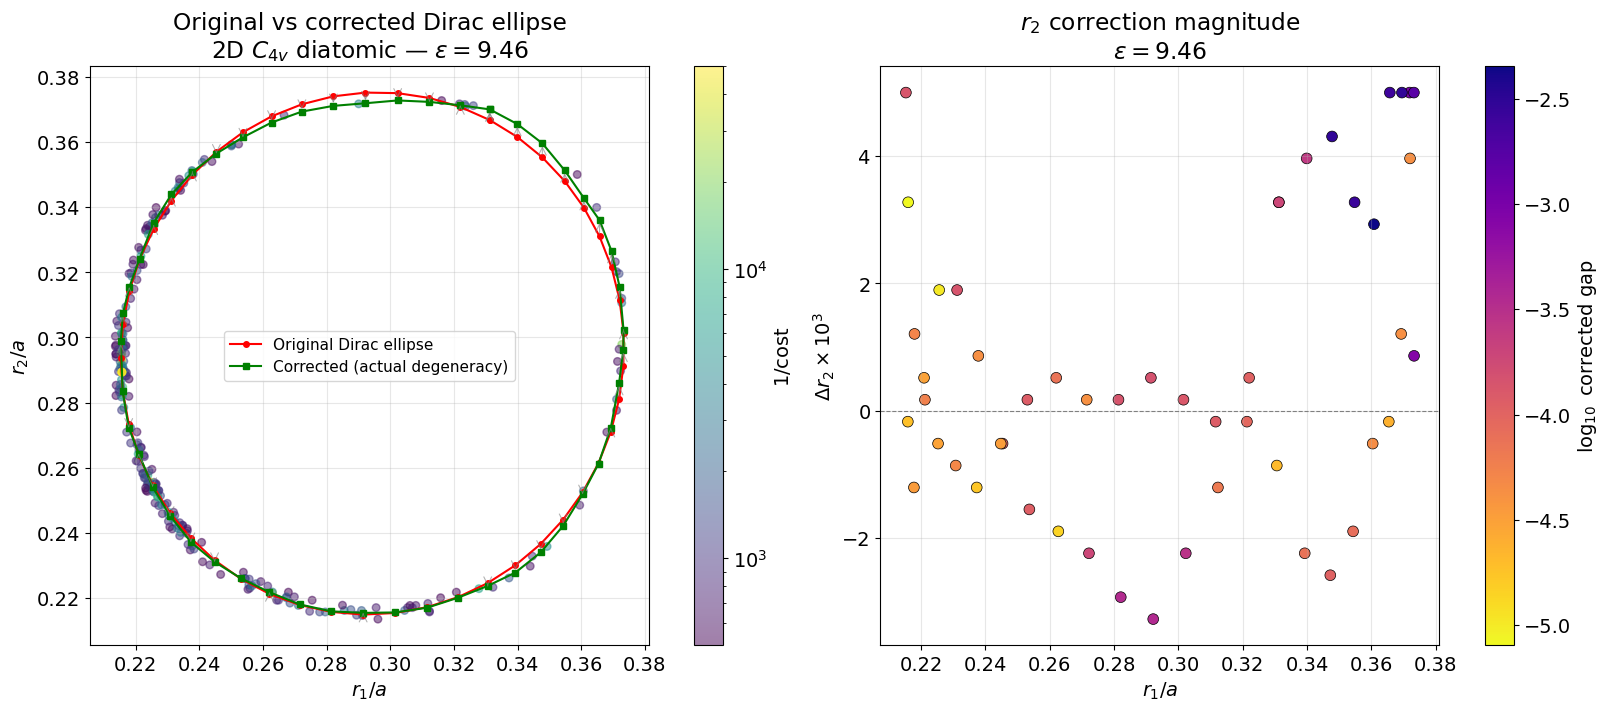


Running 50 linearity simulations with corrected r2...
Running 50 linearity sims with 20 workers...
  [6/50] r1=0.2821, r2=0.3712 done
  [3/50] r1=0.3123, r2=0.3724 done
  [1/50] r1=0.3312, r2=0.3701 done
  [2/50] r1=0.3220, r2=0.3713 done
  [5/50] r1=0.2922, r2=0.3720 done
  [4/50] r1=0.3023, r2=0.3728 done
  [8/50] r1=0.2627, r2=0.3660 done
  [13/50] r1=0.2256, r2=0.3353 done
  [10/50] r1=0.2453, r2=0.3565 done
  [9/50] r1=0.2537, r2=0.3615 done
  [14/50] r1=0.2212, r2=0.3242 done
  [7/50] r1=0.2722, r2=0.3694 done
  [16/50] r1=0.2160, r2=0.3074 done
  [11/50] r1=0.2378, r2=0.3509 done
  [12/50] r1=0.2312, r2=0.3440 done
  [15/50] r1=0.2179, r2=0.3154 done
  [19/50] r1=0.2178, r2=0.2723 done
  [17/50] r1=0.2153, r2=0.2988 done
  [18/50] r1=0.2159, r2=0.2834 done
  [20/50] r1=0.2209, r2=0.2643 done
  [21/50] r1=0.2253, r2=0.2541 done
  [31/50] r1=0.3116, r2=0.2170 done
  [33/50] r1=0.3306, r2=0.2237 done
  [22/50] r1=0.2308, r2=0.2452 done
  [28/50] r1=0.2814, r2=0.2159 done
  [32/50]

In [ ]:
# ================================================================
# For each of the 40 ellipse points, fix r1 and sweep r2 at Γ
# to find the EXACT band 4–6 degeneracy — using parallel ParamSweepers
# ================================================================
import time
from concurrent.futures import ThreadPoolExecutor, as_completed
from phc_nzi.sweeper import ParamSweeper

n_r2_sweep = 30          # number of r2 values per point
r2_half_width = 0.005    # search range: r2_original ± this
N_WORKERS = 20            # number of sweepers to run in parallel

# Gamma-only configuration → very fast per simulation
config_deg = dict(
    resolution=RESOLUTION,
    num_bands=8,
    k_points=[mp.Vector3(0, 0, 0)],
)
mpb_config_deg = MPBSchemeConfigurator(photonic_crystal_2D, ["te"], **config_deg)
script_deg = mpb_config_deg.get_scheme_config(join_newline=True)

total_sims = len(r1_ell) * n_r2_sweep
print(f"Sweeping r2 for {len(r1_ell)} points × {n_r2_sweep} r2 values = {total_sims} Γ-only simulations")

# Build one ParamSweeper per ellipse point
sweeper_entries = []
for i in range(len(r1_ell)):
    r1_i = r1_ell[i]
    r2_orig = r2_ell[i]
    r2_lo = max(0.05, r2_orig - r2_half_width)
    r2_hi = min(0.49, r2_orig + r2_half_width)
    r2_sweep = np.linspace(r2_lo, r2_hi, n_r2_sweep)

    sim_deg = Simulation(
        simulation_name=f"{name_2D_optimized}_deg_sweep_{i:03d}",
        script=script_deg,
        directory=os.path.join(data_rooth, f"{name_2D_optimized}_deg_sweep_{i:03d}")
    )
    sweeper = ParamSweeper(
        simulation=sim_deg,
        param_name="r2",
        values=r2_sweep.tolist(),
        polarization="te",
        bands=[4, 6],
        other_command_line_params={"r1": r1_i}
    )
    sweeper_entries.append({
        'idx': i, 'r1': r1_i, 'r2_orig': r2_orig,
        'r2_sweep': r2_sweep, 'sweeper': sweeper
    })

t0 = time.time()

# Auto-detect which sweepers have results
sweepers_to_run = [e for e in sweeper_entries if not sweeper_has_results(e['sweeper'], expected_count=n_r2_sweep)]
n_sweepers_cached = len(sweeper_entries) - len(sweepers_to_run)
print(f"{n_sweepers_cached}/{len(sweeper_entries)} sweepers already cached, {len(sweepers_to_run)} need to run")

def run_and_analyze(entry, do_run=True):
    """Run one sweeper (if needed) and return the corrected-point dict."""
    sw = entry['sweeper']
    if do_run:
        sw.run()
    data = sw.data if len(sw.data) > 0 else sw.load_df()
    gaps = (data['band_6'] - data['band_4']).abs().values
    best = int(np.argmin(gaps))
    r2_corr = entry['r2_sweep'][best]

    if best == 0 or best == n_r2_sweep - 1:
        print(f"  ⚠ [{entry['idx']+1:2d}/{len(r1_ell)}] r1={entry['r1']:.4f}: "
              f"minimum at EDGE of sweep range — consider widening r2_half_width")

    return {
        'idx': entry['idx'],
        'r1': entry['r1'],
        'r2_original': entry['r2_orig'],
        'r2_corrected': r2_corr,
        'gap_corrected': gaps[best],
        'delta_r2': r2_corr - entry['r2_orig'],
    }

# Run sweepers that need running
if sweepers_to_run:
    print(f"Running {len(sweepers_to_run)} sweepers in parallel...")
    with ThreadPoolExecutor(max_workers=N_WORKERS) as pool:
        futures = {pool.submit(run_and_analyze, e, True): e for e in sweepers_to_run}
        for fut in as_completed(futures):
            result = fut.result()
            idx = futures[fut]['idx']
            print(f"  [{idx+1:2d}/{len(r1_ell)}] r1={result['r1']:.4f}: "
                  f"r2={result['r2_original']:.4f} → {result['r2_corrected']:.4f} ")

# Analyze all sweepers (cached + newly run)
print("Analyzing all sweeper results...")
corrected_points = []
with ThreadPoolExecutor(max_workers=N_WORKERS) as pool:
    futures = {pool.submit(run_and_analyze, e, False): e for e in sweeper_entries}
    for fut in as_completed(futures):
        result = fut.result()
        corrected_points.append(result)
corrected_points.sort(key=lambda x: x['idx'])

df_corr = pd.DataFrame(corrected_points)
print(f"\nDone in {time.time()-t0:.0f}s")
print(f"Mean |Δr2| = {df_corr['delta_r2'].abs().mean():.5f}")
print(f"Max  |Δr2| = {df_corr['delta_r2'].abs().max():.5f}")
print(f"Mean gap_corrected = {df_corr['gap_corrected'].mean():.2e}")

# ================================================================
# Plot: Original vs Corrected ellipse
# ================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)

# Left panel: both ellipses on the cost landscape
ax = axes[0]
df_opt = analyzer.get_points_above_treshold(threshold_lin)
sc = ax.scatter(df_opt[p1], df_opt[p2], c=1/df_opt["cost"], cmap="viridis",
                norm=colors.LogNorm(vmin=(1/df_opt["cost"]).min(),
                                    vmax=(1/df_opt["cost"]).max()),
                s=30, alpha=0.5)
plt.colorbar(sc, ax=ax, label=r"$1/\mathrm{cost}$")
ax.plot(r1_ell, r2_ell, "ro-", ms=4, lw=1.5, label="Original Dirac ellipse")
ax.plot(df_corr['r1'], df_corr['r2_corrected'], "gs-", ms=4, lw=1.5,
        label="Corrected (actual degeneracy)")
# Draw arrows from original to corrected
for _, row in df_corr.iterrows():
    if abs(row['delta_r2']) > 5e-4:
        ax.annotate("", xy=(row['r1'], row['r2_corrected']),
                     xytext=(row['r1'], row['r2_original']),
                     arrowprops=dict(arrowstyle="->", color="gray", alpha=0.6, lw=0.8))
ax.set_xlabel("$r_1/a$")
ax.set_ylabel("$r_2/a$")
ax.set_title(f"Original vs corrected Dirac ellipse\n"
             f"2D $C_{{4v}}$ diatomic — $\\varepsilon={eps_inp}$")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Right panel: Δr2 correction magnitude, colored by residual gap
ax = axes[1]
sc2 = ax.scatter(df_corr['r1'], df_corr['delta_r2'] * 1e3,
                 c=np.log10(df_corr['gap_corrected'].clip(lower=1e-10)),
                 cmap='plasma_r', s=60, edgecolors='k', linewidth=0.5)
plt.colorbar(sc2, ax=ax, label=r'$\log_{10}$ corrected gap')
ax.axhline(0, color='gray', ls='--', lw=0.8)
ax.set_xlabel("$r_1/a$")
ax.set_ylabel(r"$\Delta r_2 \times 10^3$")
ax.set_title(f"$r_2$ correction magnitude\n$\\varepsilon={eps_inp}$")
ax.grid(True, alpha=0.3)

plt.show()

# ================================================================
# Create corrected sims_lin and run with k_points_around_gamma
# ================================================================
print(f"\nPreparing {len(df_corr)} linearity simulations with corrected r2...")
sims_lin = []
for i, row in df_corr.iterrows():
    sim_name = f"{name_2D_optimized}_lin_corr_{i:03d}"
    sim = Simulation(
        simulation_name=sim_name,
        script=script_lin,
        directory=os.path.join(data_rooth, sim_name)
    )
    sims_lin.append({'r1': row['r1'], 'r2': row['r2_corrected'], 'sim': sim})

# Auto-detect which corrected linearity sims need to run
corr_to_run = [(j, e) for j, e in enumerate(sims_lin) if not simulation_has_results(e['sim'])]
n_corr_cached = len(sims_lin) - len(corr_to_run)
print(f"{n_corr_cached}/{len(sims_lin)} corrected linearity sims already cached, {len(corr_to_run)} need to run")

if corr_to_run:
    def run_lin_sim(args):
        j, entry = args
        entry['sim'].run_hpc(
            mpb_command_line_params=dict(r1=entry['r1'], r2=entry['r2']),
            mpi=True, load_epsilon=False)
        return j

    print(f"Running {len(corr_to_run)} linearity sims with {N_WORKERS} workers...")
    with ThreadPoolExecutor(max_workers=N_WORKERS) as pool:
        futures = {pool.submit(run_lin_sim, (j, sims_lin[j])): j for j, _ in corr_to_run}
        for fut in as_completed(futures):
            j = fut.result()
            print(f"  [{j+1}/{len(sims_lin)}] r1={sims_lin[j]['r1']:.4f}, r2={sims_lin[j]['r2']:.4f} done")
    print(f"\nAll {len(corr_to_run)} corrected simulations completed.")
else:
    print("All corrected linearity simulations cached — no simulations needed.")

Analyzed 50/50 simulations


,r1,r2,filling_factor,c_linear,b_quad,a_cubic,fom,r_squared,gap_46,gap_norm,anisotropy
count,50.000000,50.000000,50.000000,5.000000e+01,5.000000e+01,5.000000e+01,50.000000,50.000000,50.000000,50.000000,50.000000
mean,0.295084,0.297226,0.428810,7.200013e-05,1.559160e-06,7.895919e-09,1.003151,0.970934,0.000466,0.000622,0.970275
std,0.056159,0.058086,0.153339,8.578952e-05,1.909790e-06,1.630575e-08,1.249491,0.027352,0.000967,0.001240,0.094922
min,0.215269,0.215384,0.213704,1.159508e-07,2.435897e-07,1.207003e-10,0.002422,0.920034,0.000008,0.000014,0.376538
25%,0.239535,0.238413,0.278858,3.410284e-06,4.765738e-07,4.221793e-10,0.075252,0.940163,0.000042,0.000063,0.992986
50%,0.296877,0.300588,0.428502,5.497265e-05,8.219918e-07,1.083327e-09,0.498247,0.986024,0.000105,0.000156,0.999007
75%,0.347644,0.355211,0.572491,1.070255e-04,1.228882e-06,4.388059e-09,1.284535,0.995314,0.000190,0.000266,0.999702
max,0.373284,0.372820,0.646400,3.926174e-04,8.242506e-06,6.898696e-08,4.496532,0.999563,0.004514,0.005803,0.999996


Outlier filter: removed 0 point(s) with FOM > 5
Gaussian fit: A = 3.625 ± 0.223, μ = 0.3806 ± 0.0043, σ = 0.0616 ± 0.0041
Gaussian fit R² = 0.8226  (computed on 50 / 50 points)


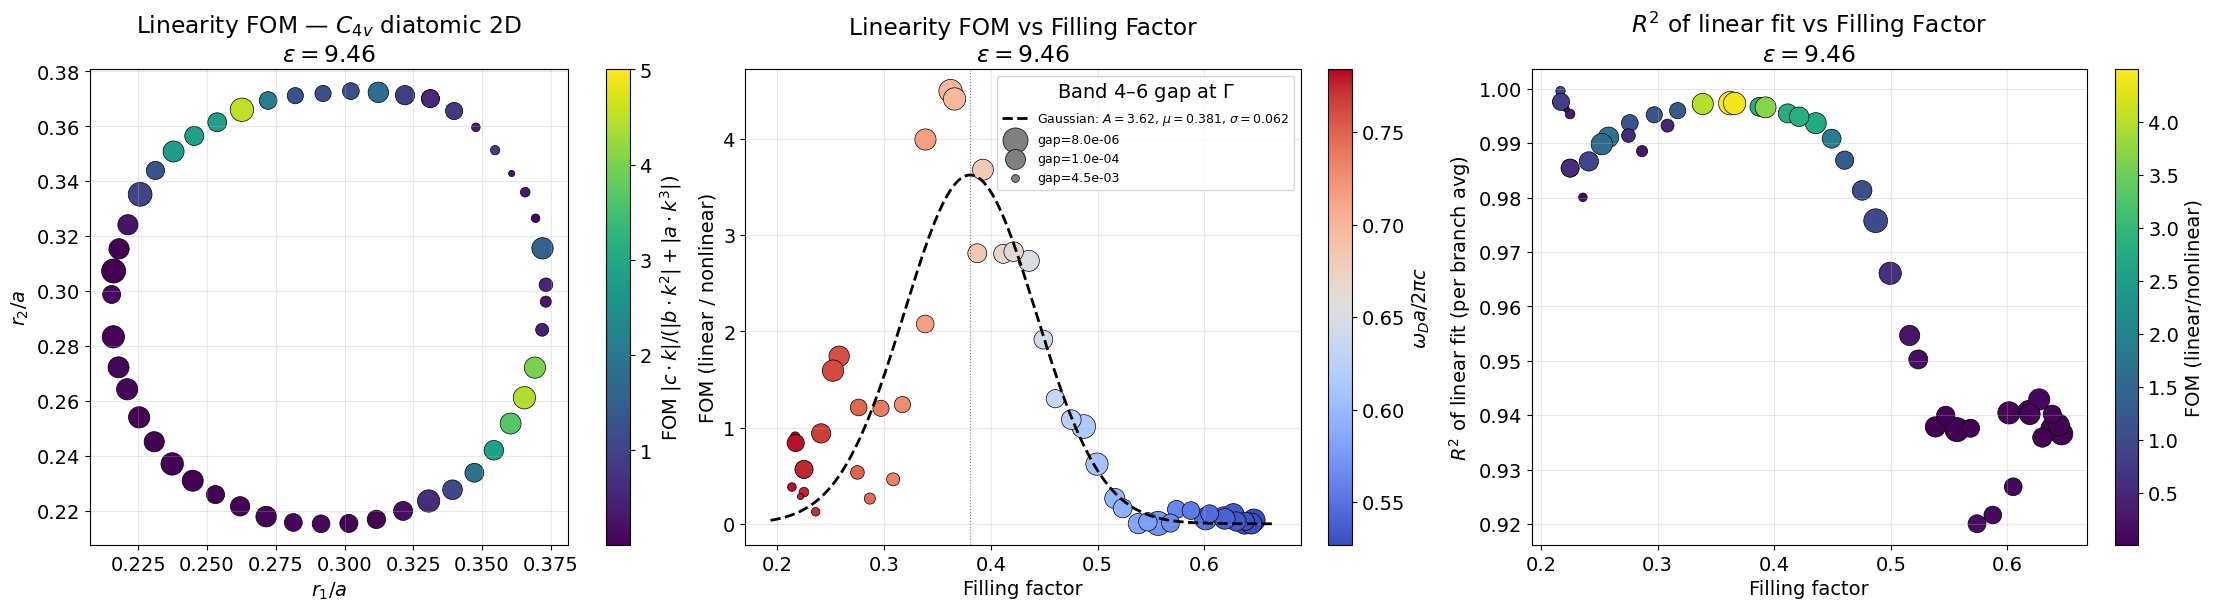

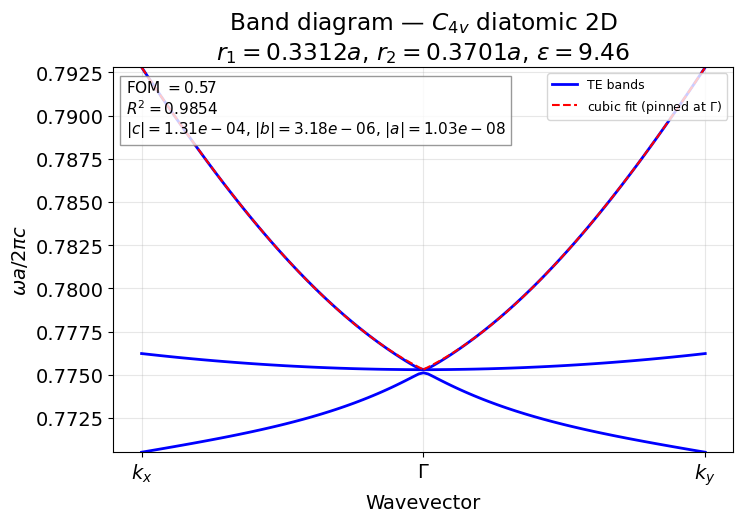

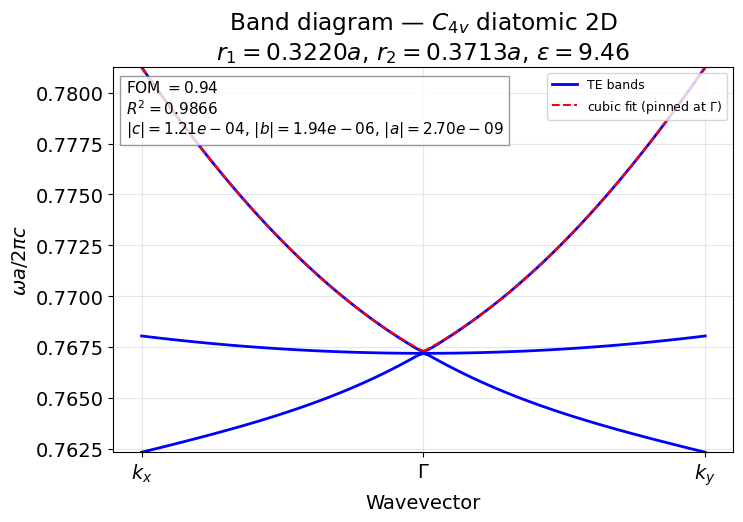

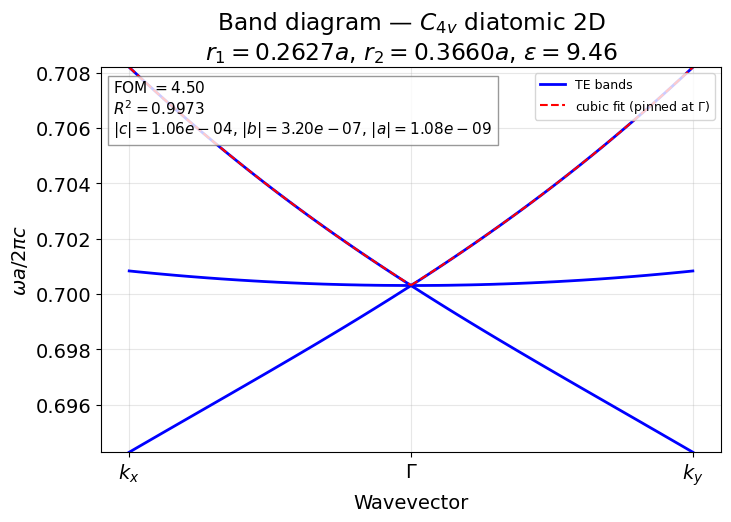

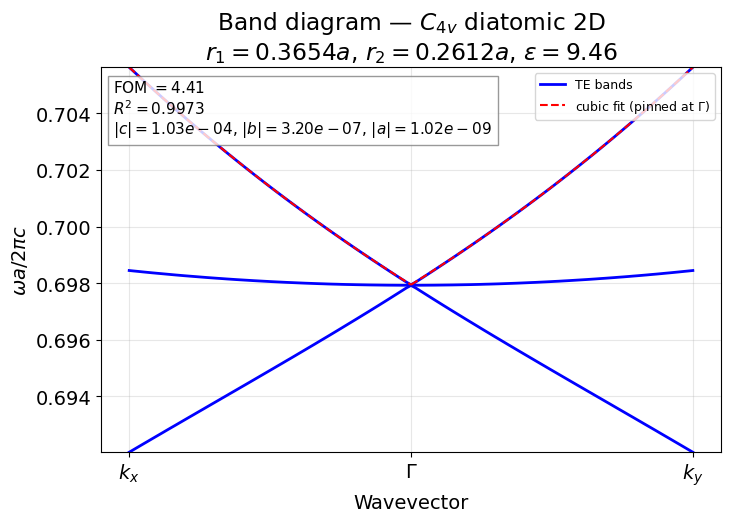

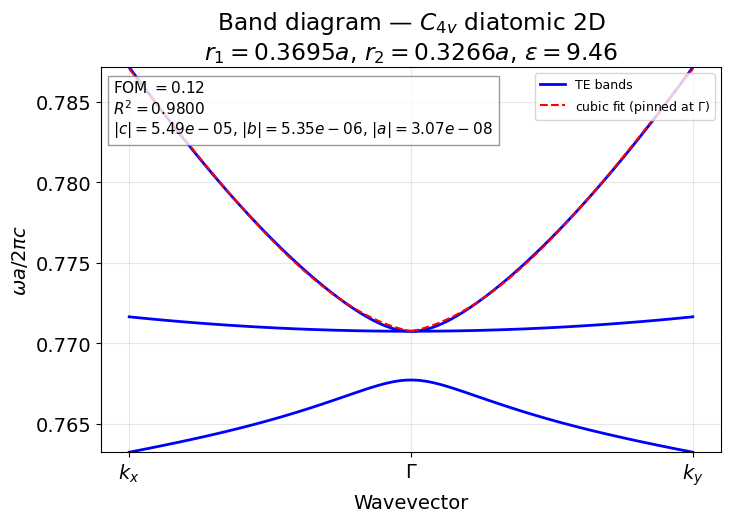

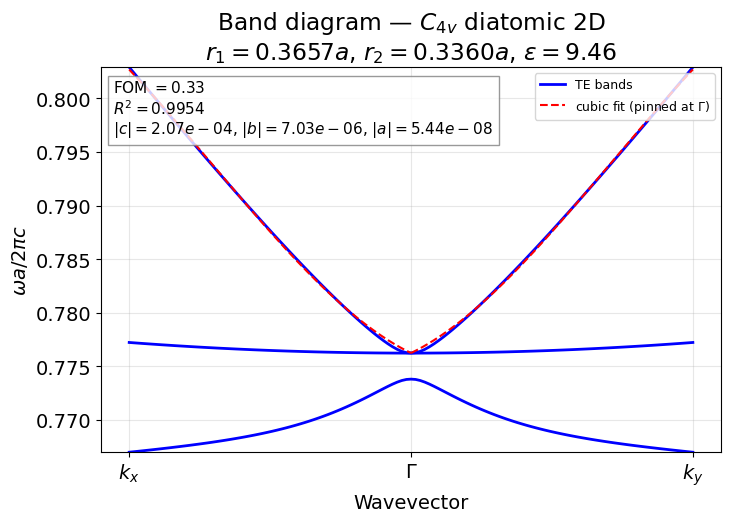

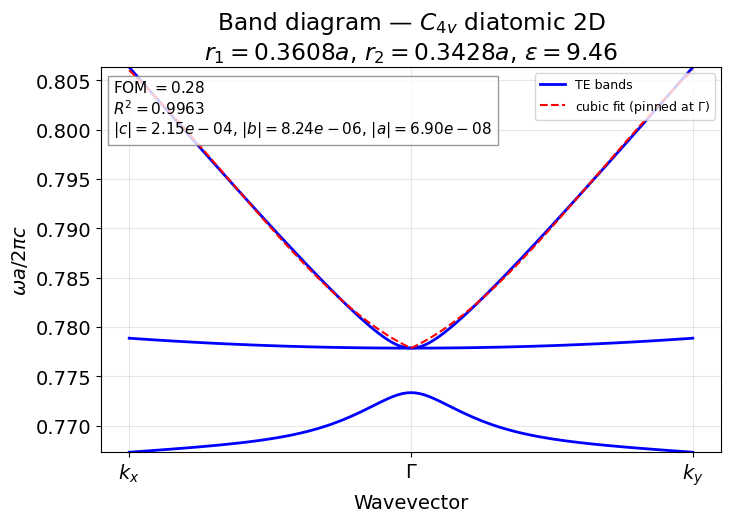

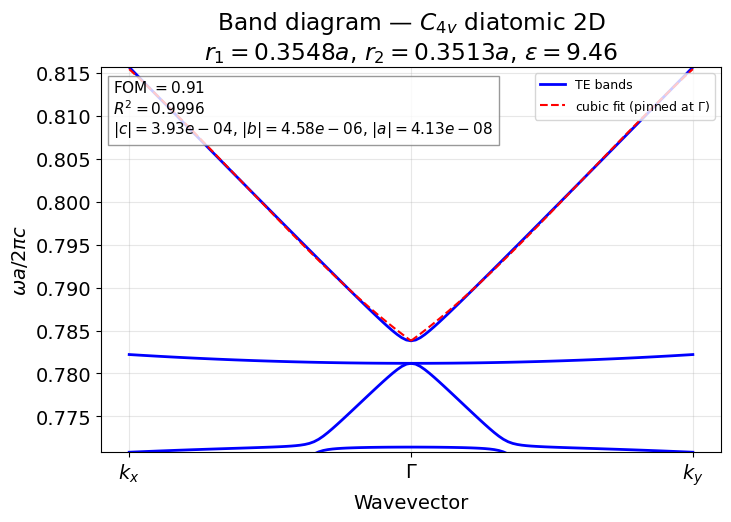

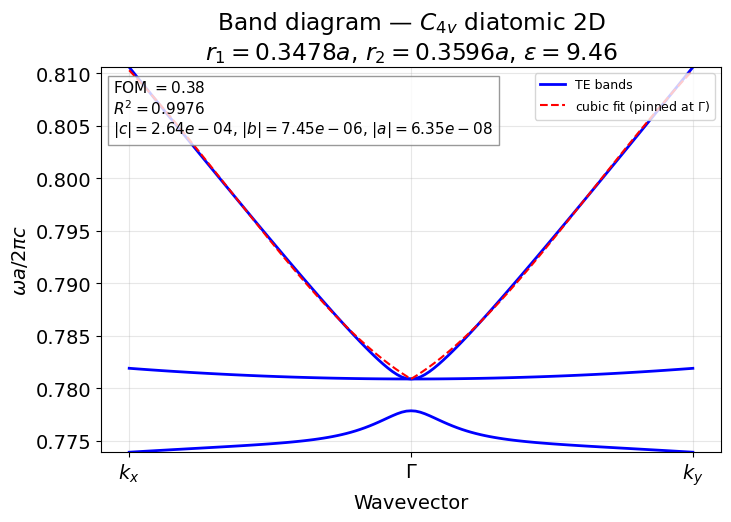

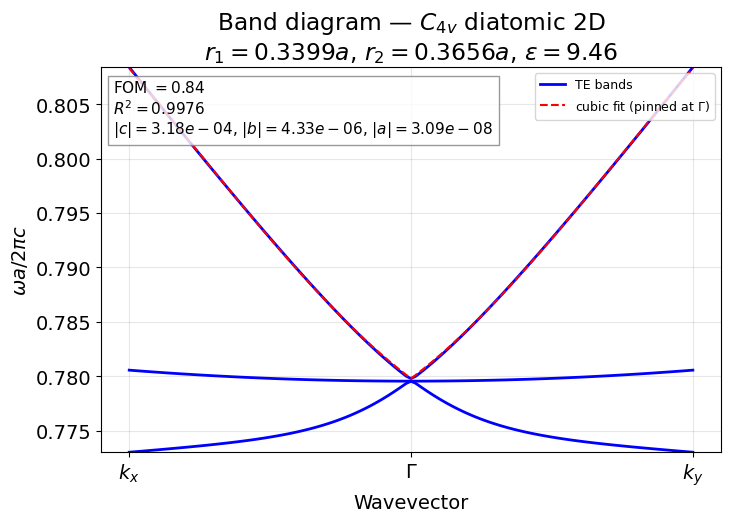

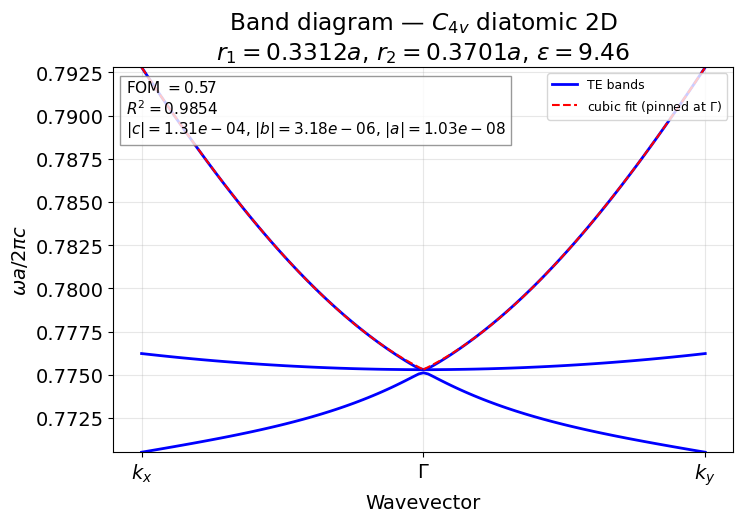

Saved 50 band diagrams to:
  /work3/enrva/phc_nzi_data/MPB_data/C4v_diatomic_holes_1_2D_optimized_linearity_bands


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress
from scipy.optimize import curve_fit
import os

# ======================== USER SETTINGS ========================
FIT_ORDER = 4          # polynomial order for the fit (change to 3, 5, 6, … as needed)
FOM_THRESHOLD = 5      # outlier filter for Gaussian fit
# ===============================================================

# Analyze linearity of band 6 (top band of Dirac triplet 4,5,6)
# Fit ω(Δk) with np.polyfit of order FIT_ORDER, then pin the constant
# term to ω_Γ so the fit passes through the Γ point exactly.
# FOM = |c·Δk_max| / Σ|higher-order contributions at Δk_max|
results_lin = []
top_band_name = "te band 6"

for entry in sims_lin:
    r1_i, r2_i, sim = entry['r1'], entry['r2'], entry['sim']
    try:
        df_freq = sim.load_frequency_data("te")
        k_idx = df_freq["k index"].values.astype(float)
        freqs = df_freq[top_band_name].values

        # Gamma is at the center of the k-path
        gamma_pos = len(k_idx) // 2
        omega_gamma = freqs[gamma_pos]
        k_gamma = k_idx[gamma_pos]

        # Center k at Gamma: Δk = k - k_Γ
        dk_all = k_idx - k_gamma

        # Split into branches
        dk_left  = dk_all[:gamma_pos + 1]
        f_left   = freqs[:gamma_pos + 1]
        dk_right = dk_all[gamma_pos:]
        f_right  = freqs[gamma_pos:]

        # Polyfit each branch, then pin constant to omega_gamma
        coeffs_L = np.polyfit(dk_left, f_left, FIT_ORDER)
        coeffs_L[-1] = omega_gamma

        coeffs_R = np.polyfit(dk_right, f_right, FIT_ORDER)
        coeffs_R[-1] = omega_gamma

        # Extract linear coeff (second-to-last) and higher-order coeffs
        # coeffs = [a_N, a_{N-1}, ..., a_2, a_1 (linear), a_0 (const)]
        c_L = coeffs_L[-2]   # linear
        c_R = coeffs_R[-2]

        # Average absolute coefficients from both branches
        c_avg = 0.5 * (abs(c_L) + abs(c_R))

        # Average absolute nonlinear coefficients (order 2 .. N)
        nonlin_coeffs_L = coeffs_L[:-2]  # all except linear and constant
        nonlin_coeffs_R = coeffs_R[:-2]
        nonlin_avg = 0.5 * (np.abs(nonlin_coeffs_L) + np.abs(nonlin_coeffs_R))

        # For backward-compatible column names: cubic and quadratic averages
        # (pad with 0 if FIT_ORDER < 3)
        a_avg = nonlin_avg[-3] if len(nonlin_avg) >= 3 else 0.0  # cubic
        b_avg = nonlin_avg[-2] if len(nonlin_avg) >= 2 else 0.0  # quadratic
        # Also store all higher-order averages for the FOM
        higher_avg = nonlin_avg  # from highest to lowest nonlinear order

        # k_max = max |Δk| across both branches
        dk_max = max(abs(dk_left.min()), abs(dk_right.max()))

        # FOM = |linear contribution| / |sum of all nonlinear contributions| at k_max
        linear_contrib = c_avg * dk_max
        # nonlinear contributions: sum_{n=2}^{N} |avg_coeff_n| * dk_max^n
        nonlinear_contrib = 0.0
        for idx_c, coeff_val in enumerate(higher_avg):
            power = FIT_ORDER - idx_c   # highest order first
            nonlinear_contrib += abs(coeff_val) * dk_max**power
        fom = linear_contrib / nonlinear_contrib if nonlinear_contrib > 1e-30 else np.inf

        # R² of a purely linear fit — per branch, then averaged
        _, _, r_L, _, _ = linregress(dk_left, f_left)
        _, _, r_R, _, _ = linregress(dk_right, f_right)
        r_squared = 0.5 * (r_L**2 + r_R**2)

        # Isotropy: compare group velocities along kx and ky branches
        anisotropy = min(abs(c_L), abs(c_R)) / max(abs(c_L), abs(c_R)) if max(abs(c_L), abs(c_R)) > 0 else np.nan

        # Gap between band 6 and band 4 at Gamma
        freqs_b4 = df_freq["te band 4"].values
        freqs_b6 = df_freq["te band 6"].values
        gap_46 = abs(freqs_b6[gamma_pos] - freqs_b4[gamma_pos])

        results_lin.append({
            'r1': r1_i, 'r2': r2_i,
            'filling_factor': 1 - np.pi * (r1_i**2 + r2_i**2),
            'a_cubic': a_avg,
            'b_quad': b_avg,
            'c_linear': c_avg,
            'fom': fom,
            'r_squared': r_squared,
            'omega_dirac': omega_gamma,
            'v_group': c_avg,
            'anisotropy': anisotropy,
            'gap_46': gap_46,
            'dk_max': dk_max,
            'gap_norm': gap_46 / omega_gamma
        })
    except Exception as e:
        print(f"  Error r1={r1_i:.4f}, r2={r2_i:.4f}: {e}")

df_lin = pd.DataFrame(results_lin)
print(f"Analyzed {len(df_lin)}/{len(sims_lin)} simulations  (FIT_ORDER={FIT_ORDER})")
if len(df_lin) > 0:
    display(df_lin[['r1','r2','filling_factor','c_linear','b_quad','a_cubic',
                     'fom','r_squared','gap_46','gap_norm','anisotropy']].describe())
else:
    print("WARNING: No results — check errors above")

# Dot size: inversely proportional to gap (log-scaled)
log_gap = np.log10(df_lin['gap_norm'].clip(lower=1e-10))
log_gap_min, log_gap_max = log_gap.min(), log_gap.max()
size_min, size_max = 20, 300
dot_sizes = size_min + (size_max - size_min) * (1 - (log_gap - log_gap_min) / (log_gap_max - log_gap_min))

# ===========================================================================
# 3-panel figure
# ===========================================================================
fig, axes = plt.subplots(1, 3, figsize=(22, 6), constrained_layout=True)

ax = axes[0]
sc = ax.scatter(df_lin['r1'], df_lin['r2'], c=df_lin['fom'],
                cmap='viridis', s=dot_sizes, edgecolors='k', linewidth=0.5,
                vmax=FOM_THRESHOLD)
fig.colorbar(sc, ax=ax, label='FOM (linear / nonlinear)')
ax.set_xlabel('$r_1/a$')
ax.set_ylabel('$r_2/a$')
ax.set_title(f'Linearity FOM — $C_{{4v}}$ diatomic 2D\n$\\varepsilon={eps_inp}$, polyfit order {FIT_ORDER}')
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

ax = axes[1]
sc2 = ax.scatter(df_lin['filling_factor'], df_lin['fom'],
                 c=df_lin['omega_dirac'], cmap='coolwarm', s=dot_sizes,
                 edgecolors='k', linewidth=0.5)
fig.colorbar(sc2, ax=ax, label='$\\omega_D a / 2\\pi c$')
ax.set_xlabel('Filling factor')
ax.set_ylabel('FOM (linear / nonlinear)')
ax.set_title(f'Linearity FOM vs Filling Factor\n$\\varepsilon={eps_inp}$')
ax.grid(True, alpha=0.3)

# Gaussian fit of FOM vs filling factor
def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

ff_data = df_lin['filling_factor'].values
fom_data = df_lin['fom'].values

mask = fom_data <= FOM_THRESHOLD
n_outliers = int((~mask).sum())
print(f"Outlier filter: removed {n_outliers} point(s) with FOM > {FOM_THRESHOLD}")

if mask.sum() > 5:
    idx_max_clean = np.argmax(fom_data[mask])
    p0 = [fom_data[mask][idx_max_clean], ff_data[mask][idx_max_clean], 0.1]

    try:
        popt, pcov = curve_fit(
            gaussian, ff_data[mask], fom_data[mask], p0=p0,
            bounds=([0, ff_data.min() - 0.1, 1e-4],
                    [np.inf, ff_data.max() + 0.1, 1.0]),
            maxfev=50000,
        )
        perr = np.sqrt(np.diag(pcov))

        ff_fine = np.linspace(ff_data.min() - 0.02, ff_data.max() + 0.02, 200)
        ax.plot(ff_fine, gaussian(ff_fine, *popt), 'k--', lw=2,
                label=f'Gaussian: $A={popt[0]:.2f}$, $\\mu={popt[1]:.3f}$, $\\sigma={popt[2]:.3f}$')
        ax.axvline(popt[1], color='k', ls=':', lw=0.8, alpha=0.5)
        if n_outliers > 0:
            ax.scatter(ff_data[~mask], fom_data[~mask], marker='x', s=80,
                       c='red', linewidths=2, zorder=5, label=f'Outliers ({n_outliers})')
        print(f"Gaussian fit: A = {popt[0]:.3f} ± {perr[0]:.3f}, "
              f"μ = {popt[1]:.4f} ± {perr[1]:.4f}, "
              f"σ = {popt[2]:.4f} ± {perr[2]:.4f}")
        fom_clean = fom_data[mask]
        ff_clean  = ff_data[mask]
        ss_res = np.sum((fom_clean - gaussian(ff_clean, *popt))**2)
        ss_tot = np.sum((fom_clean - fom_clean.mean())**2)
        r2_gauss = 1 - ss_res / ss_tot
        print(f"Gaussian fit R² = {r2_gauss:.4f}  (computed on {mask.sum()} / {len(ff_data)} points)")
    except Exception as e_fit:
        print(f"Gaussian fit failed: {e_fit}")

# Size legend
gap_legend_vals = [df_lin['gap_46'].min(), df_lin['gap_46'].median(), df_lin['gap_46'].max()]
for gap_val in gap_legend_vals:
    lg = np.log10(max(gap_val, 1e-10))
    s_val = size_min + (size_max - size_min) * (1 - (lg - log_gap_min) / (log_gap_max - log_gap_min))
    ax.scatter([], [], s=s_val, c='gray', edgecolors='k', linewidth=0.5,
               label=f'gap={gap_val:.1e}')
ax.legend(title='Band 4–6 gap at $\\Gamma$', loc='best', fontsize=9)

ax = axes[2]
sc3 = ax.scatter(df_lin['filling_factor'], df_lin['r_squared'],
                 c=df_lin['fom'], cmap='viridis', s=dot_sizes,
                 edgecolors='k', linewidth=0.5)
fig.colorbar(sc3, ax=ax, label='FOM (linear/nonlinear)')
ax.set_xlabel('Filling factor')
ax.set_ylabel('$R^2$ of linear fit (per branch avg)')
ax.set_title(f'$R^2$ of linear fit vs Filling Factor\n$\\varepsilon={eps_inp}$')
ax.grid(True, alpha=0.3)

plt.show()

# ===========================================================================
# Band diagrams with fit overlay
# ===========================================================================
band_fig_dir = os.path.join(data_rooth, f"{name_2D_optimized}_linearity_bands")
os.makedirs(band_fig_dir, exist_ok=True)

plt.rcParams["font.size"] = 14
plt.rcParams["lines.linewidth"] = 2

for j, entry in enumerate(sims_lin):
    r1_j, r2_j, sim_j = entry['r1'], entry['r2'], entry['sim']
    viewer_j = SimulationViewer(sim_j)

    fig_j, ax_j = plt.subplots(figsize=(8, 5))
    plt.sca(ax_j)
    viewer_j.plot_band_diagram("te", k_points_path=k_points_around_gamma, color="blue")
    ax_j.set_ylabel(r"$\omega a / 2\pi c$")
    ax_j.set_title(
        f"Band diagram — $C_{{4v}}$ diatomic 2D\n"
        f"$r_1={r1_j:.4f}a$, $r_2={r2_j:.4f}a$, "
        f"$\\varepsilon={eps_inp}$"
    )
    ax_j.grid(True, alpha=0.3)

    df = sim_j.load_frequency_data("te")
    k_vals = df["k index"].values.astype(float)
    freqs_b6 = df["te band 6"].values
    ymax = freqs_b6.max()
    ymin = df["te band 4"].values.min()
    ax_j.set_ylim(ymin, ymax)

    # Overlay polyfit on band 6, pinned at ω_Γ
    try:
        gamma_pos = len(k_vals) // 2
        k_gamma = k_vals[gamma_pos]
        omega_g = freqs_b6[gamma_pos]
        dk_vals = k_vals - k_gamma

        # Left branch
        dk_left = dk_vals[:gamma_pos + 1]
        f_left = freqs_b6[:gamma_pos + 1]
        coeffs_L = np.polyfit(dk_left, f_left, FIT_ORDER)
        coeffs_L[-1] = omega_g
        dks_L = np.linspace(dk_left.min(), dk_left.max(), 150)
        ax_j.plot(dks_L + k_gamma, np.polyval(coeffs_L, dks_L), 'r--', linewidth=1.5)

        # Right branch
        dk_right = dk_vals[gamma_pos:]
        f_right = freqs_b6[gamma_pos:]
        coeffs_R = np.polyfit(dk_right, f_right, FIT_ORDER)
        coeffs_R[-1] = omega_g
        dks_R = np.linspace(dk_right.min(), dk_right.max(), 150)
        ax_j.plot(dks_R + k_gamma, np.polyval(coeffs_R, dks_R), 'r--', linewidth=1.5,
                  label=f'order-{FIT_ORDER} fit (pinned at $\\Gamma$)')
        ax_j.legend(fontsize=9, loc='upper right')
    except Exception:
        pass

    # Show FOM annotation
    try:
        row = df_lin.iloc[j]
        ax_j.text(0.02, 0.97,
                  f"FOM $= {row['fom']:.2f}$\n"
                  f"$R^2 = {row['r_squared']:.4f}$\n"
                  f"$|c|={row['c_linear']:.2e}$, $|b|={row['b_quad']:.2e}$, $|a|={row['a_cubic']:.2e}$",
                  transform=ax_j.transAxes, va='top', fontsize=11,
                  bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))
    except Exception:
        pass

    fig_path = os.path.join(band_fig_dir, f"band_diagram_{j:03d}_r1_{r1_j:.4f}_r2_{r2_j:.4f}.png")
    fig_j.savefig(fig_path, dpi=150, bbox_inches='tight')

    ## plot the one with the best FOM
    if j == np.argmax(df_lin['fom'].values):
        plt.show()
    ## plot the second best FOM
    elif j == np.argsort(df_lin['fom'].values)[-2]:
        plt.show()
    # Plot the ones with FF less than 0.25
    elif row['filling_factor'] < 0.25:
        plt.show()
    else:
        plt.close(fig_j)

print(f"Saved {len(sims_lin)} band diagrams to:\n  {band_fig_dir}")

In [ ]:
# Plot epsilon of the outlier (FOM > 2)
outlier_idx = np.where(~mask)[0]  # indices where mask is False (outliers)
print(f"Outlier indices: {outlier_idx}")

for oi in outlier_idx:
    entry_out = sims_lin[oi]
    r1_out, r2_out, sim_out = entry_out['r1'], entry_out['r2'], entry_out['sim']
    viewer_out = SimulationViewer(sim_out)
    opt_out = MPBDataOptions(rectify=True, periods=1)

    fig_out, ax_out = plt.subplots(figsize=(6, 6))
    plt.sca(ax_out)
    viewer_out.plot_epsilon_2d(conversion_options=opt_out)
    ax_out.set_title(
        f"$\\varepsilon$ — Outlier (FOM = {df_lin.iloc[oi]['fom']:.2f})\n"
        f"$r_1 = {r1_out:.4f}a$, $r_2 = {r2_out:.4f}a$, "
        f"$\\varepsilon_{{\\mathrm{{bulk}}}} = {eps_inp}$"
    )
    plt.show()

In [ ]:
# ===========================================================================
# FOM vs Concentration Factor
# ===========================================================================
# CF(band) ≜  ∫_diel ε|E|² / ∫_all ε|E|²   at Γ
# FOM is always from band-6 linearity (computed above)
# ===========================================================================

# --- Gamma-only config WITH E-field output ---
config_cf = dict(
    resolution=RESOLUTION,
    num_bands=8,
    k_points=[mp.Vector3(0, 0, 0)],
    extra_runner_command="output-efield",
)
mpb_config_cf = MPBSchemeConfigurator(photonic_crystal_2D, ["te"], **config_cf)
script_cf = mpb_config_cf.get_scheme_config(join_newline=True)

# --- One Simulation per corrected ellipse point ---
sims_cf = []
for i, row in df_corr.iterrows():
    sim_name = f"{name_2D_optimized}_cf_{i:03d}"
    sim_cf = Simulation(
        simulation_name=sim_name,
        script=script_cf,
        directory=os.path.join(data_rooth, sim_name),
    )
    sims_cf.append({'r1': row['r1'], 'r2': row['r2_corrected'], 'sim': sim_cf})

# --- Auto-detect which CF sims need to run ---
cf_to_run = [(j, e) for j, e in enumerate(sims_cf) if not simulation_has_results(e['sim'])]
n_cf_cached = len(sims_cf) - len(cf_to_run)
print(f"{n_cf_cached}/{len(sims_cf)} CF simulations already cached, {len(cf_to_run)} need to run")

if cf_to_run:
    print(f"Running {len(cf_to_run)} Γ-only simulations with E-field output ...")
    for j, entry in cf_to_run:
        print(f"  [{j+1}/{len(sims_cf)}] r1={entry['r1']:.4f}, r2={entry['r2']:.4f}",
              end=" ... ", flush=True)
        entry['sim'].run_hpc(
            mpb_command_line_params=dict(r1=entry['r1'], r2=entry['r2']),
            mpi=True, load_epsilon=False)
        print("done")
    print("All CF simulations completed.")
else:
    print("All CF simulations cached — no simulations needed.")

# --- Compute concentration factors for bands 4, 5, 6 ---
bands_cf = [4, 5, 6]
opt_cf = MPBDataOptions(rectify=True, periods=1)

cf_data = {b: [] for b in bands_cf}

for j, entry in enumerate(sims_cf):
    sim = entry['sim']
    try:
        # Load epsilon (take mid-slice if 3D)
        eps = sim.load_and_convert_epsilon_data(options=opt_cf)
        if eps.ndim == 3:
            eps = eps[:, :, eps.shape[2] // 2]

        # Dielectric mask: ε above midpoint between air (1) and bulk
        eps_mid = (1.0 + eps.max()) / 2.0
        diel_mask = eps > eps_mid

        for band in bands_cf:
            # TE in 2D → E has x, y components only (no z)
            Ex = sim.load_and_convert_field_data(
                1, band, "x", "te", "e", conversion_options=opt_cf)
            Ey = sim.load_and_convert_field_data(
                1, band, "y", "te", "e", conversion_options=opt_cf)
            if Ex.ndim == 3:
                Ex = Ex[:, :, Ex.shape[2] // 2]
            if Ey.ndim == 3:
                Ey = Ey[:, :, Ey.shape[2] // 2]

            eps_Esq = eps * (np.abs(Ex)**2 + np.abs(Ey)**2)
            total = eps_Esq.sum()
            cf = eps_Esq[diel_mask].sum() / total if total > 0 else np.nan
            cf_data[band].append(cf)

    except Exception as e:
        print(f"  Error j={j}, r1={entry['r1']:.4f}, r2={entry['r2']:.4f}: {e}")
        for band in bands_cf:
            cf_data[band].append(np.nan)

# Store in df_lin
for band in bands_cf:
    df_lin[f'cf_band_{band}'] = cf_data[band]

# --- Remove FOM outlier (same threshold used in cell 21) ---
fom_mask = df_lin['fom'] <= FOM_THRESHOLD
n_removed = int((~fom_mask).sum())
df_cf = df_lin[fom_mask].copy()
print(f"Removed {n_removed} outlier(s) with FOM > {FOM_THRESHOLD}")

print(f"\nConcentration-factor statistics (N = {len(df_cf)}):")
for band in bands_cf:
    v = df_cf[f'cf_band_{band}'].dropna()
    if len(v) > 0:
        print(f"  Band {band}: CF = {v.mean():.4f} ± {v.std():.4f}  "
              f"[{v.min():.4f}, {v.max():.4f}]")

# ===========================================================================
# 2D Plot: x = Filling Factor, y = Concentration Factor
#          dot size  ∝ FOM,  dot color  = band
# ===========================================================================
band_colors  = {4: 'tab:blue', 5: 'tab:orange', 6: 'tab:green'}
band_markers = {4: 'o', 5: 's', 6: 'D'}

fig, ax = plt.subplots(figsize=(10, 8), constrained_layout=True)

# Scale dot sizes from FOM
fom_vals = df_cf['fom'].values
size_min_cf, size_max_cf = 30, 350
fom_min, fom_max = fom_vals.min(), fom_vals.max()
if fom_max > fom_min:
    fom_norm = (fom_vals - fom_min) / (fom_max - fom_min)
else:
    fom_norm = np.ones_like(fom_vals) * 0.5
dot_sizes_cf = size_min_cf + (size_max_cf - size_min_cf) * fom_norm

for band in bands_cf:
    col = f'cf_band_{band}'
    ax.scatter(df_cf['filling_factor'], df_cf[col],
               s=dot_sizes_cf, color=band_colors[band],
               marker=band_markers[band],
               edgecolors='k', linewidth=0.5, alpha=0.8, zorder=3,
               label=f'Band {band}')

ax.set_xlabel(r'Filling factor  $1-\pi(r_1^2+r_2^2)/a^2$', fontsize=13)
ax.set_ylabel(r'Concentration factor  $\int_{\mathrm{diel}}\varepsilon|\mathbf{E}|^2'
              r'\;/\;\int_{\mathrm{all}}\varepsilon|\mathbf{E}|^2$', fontsize=13)
ax.set_title(f'Concentration Factor vs Filling Factor — $C_{{4v}}$ diatomic 2D\n'
             f'$\\varepsilon={eps_inp}$  (dot size $\\propto$ FOM)', fontsize=14)
ax.grid(True, alpha=0.3)

# Size legend for FOM values
for fom_leg in [fom_min, 0.5*(fom_min+fom_max), fom_max]:
    s_leg = size_min_cf + (size_max_cf - size_min_cf) * ((fom_leg - fom_min) / (fom_max - fom_min) if fom_max > fom_min else 0.5)
    ax.scatter([], [], s=s_leg, c='gray', edgecolors='k', linewidth=0.5,
               label=f'FOM = {fom_leg:.2f}')

ax.legend(loc='best', fontsize=10, title='Band / FOM')
plt.savefig(os.path.join(data_rooth, f"{name_2D_optimized}_cf_vs_filling_factor.png"), dpi=150)
plt.show()

We need a moderate but not excessive confinement of the doubly degenerate modes in the dielectric

### Effective parameters

In [ ]:
import phc_nzi.field_analyzer as fa

# ===========================================================================
# Effective Parameter Extraction  (ε_eff, μ_eff, n_eff, Z_eff)
# Only 6 representative points along the Dirac ellipse:
#   Left side of gaussian (lower filling factor):
#     - on the lead (edge), closer to the lead, near center
#   Right side of gaussian (higher filling factor):
#     - near center, closer to the lead, on the lead (edge)
# Outliers (FOM > FOM_THRESHOLD) are excluded before selection.
# ===========================================================================

# --- Select 6 points from df_corr based on filling factor vs gaussian center ---
ff_all = 1 - np.pi * (df_corr['r1']**2 + df_corr['r2_corrected']**2)
df_corr_sel = df_corr.copy()
df_corr_sel['filling_factor'] = ff_all

# Cross-reference with df_lin to get FOM and filter out outliers
df_corr_sel['fom'] = np.nan
for idx_cs, row_cs in df_corr_sel.iterrows():
    fom_match = df_lin.loc[
        (np.isclose(df_lin['r1'], row_cs['r1'], atol=1e-6)) &
        (np.isclose(df_lin['r2'], row_cs['r2_corrected'], atol=1e-6)),
        'fom'
    ]
    if len(fom_match) > 0:
        df_corr_sel.loc[idx_cs, 'fom'] = fom_match.values[0]

n_before = len(df_corr_sel)
df_corr_sel = df_corr_sel[df_corr_sel['fom'] <= FOM_THRESHOLD].reset_index(drop=True)
n_removed = n_before - len(df_corr_sel)
print(f"Filtered out {n_removed} outlier(s) with FOM > {FOM_THRESHOLD}  "
      f"({len(df_corr_sel)} points remaining)")

mu_gauss = popt[1]  # gaussian center from cell 21

# Split into left (ff < mu) and right (ff > mu) branches
left_mask = df_corr_sel['filling_factor'] < mu_gauss
right_mask = df_corr_sel['filling_factor'] >= mu_gauss

df_left = df_corr_sel[left_mask].sort_values('filling_factor').reset_index(drop=True)
df_right = df_corr_sel[right_mask].sort_values('filling_factor').reset_index(drop=True)

def pick_3_points(df_branch, side='left'):
    """Pick 3 points: on the lead (edge), closer to lead, near center."""
    n = len(df_branch)
    if n < 3:
        return df_branch  # fallback: use all available
    if side == 'left':
        # edge = lowest ff, center = highest ff (closest to mu)
        idx_edge = 0
        idx_center = n - 1
    else:
        # center = lowest ff (closest to mu), edge = highest ff
        idx_center = 0
        idx_edge = n - 1
    idx_mid = n // 2
    return df_branch.iloc[[idx_edge, idx_mid, idx_center]]

sel_left = pick_3_points(df_left, 'left')
sel_right = pick_3_points(df_right, 'right')
df_6pts = pd.concat([sel_left, sel_right], ignore_index=True)

print(f"Gaussian center (μ) = {mu_gauss:.4f}")
print(f"Selected 6 points for effective parameter extraction:")
for i, row in df_6pts.iterrows():
    label = "LEFT" if row['filling_factor'] < mu_gauss else "RIGHT"
    print(f"  [{i}] r1={row['r1']:.4f}, r2={row['r2_corrected']:.4f}, "
          f"ff={row['filling_factor']:.4f}, FOM={row['fom']:.2f}  ({label})")

# --- Configuration for nonbloch fields ---
k_points_eff = {
    "k_points_values": [
        mp.Vector3(0.005, 0, 0),
        mp.Vector3(0.15, 0, 0),
    ],
    "k_points_label": [
        r"$\Gamma$",
        r"$k_x$",
    ],
}

config_eff = dict(
    resolution=RESOLUTION,
    num_bands=6,
    k_points=k_points_eff["k_points_values"],
    k_points_interpolation_factor=20,
    extra_runner_command=(
        "fix-hfield-phase fix-efield-phase "
        "output-hfield output-nonbloch-efield-y output-nonbloch-hfield-z"
    ),
)
mpb_config_eff = MPBSchemeConfigurator(photonic_crystal_2D, ["te"], **config_eff)
script_eff = mpb_config_eff.get_scheme_config(join_newline=True)

# --- Cache file for effective parameters (6 points) ---
eff_cache_file = os.path.join(data_rooth, f"{name_2D_optimized}_effective_params_6pts.csv")

if os.path.exists(eff_cache_file):
    # ---- Load cached results ----
    df_eff = pd.read_csv(eff_cache_file)
    for col_name in ['eps', 'mu', 'impedance', 'n_eff']:
        df_eff[col_name] = df_eff[f'{col_name}_re'] + 1j * df_eff[f'{col_name}_im']
    print(f"Loaded cached effective parameters from:\n  {eff_cache_file}")
    print(f"  {len(df_eff)} rows, {df_eff['r1'].nunique()} unique (r1, r2) points")
else:
    # ---- Compute from field data ----
    eff_results_all = []

    for i, row in df_6pts.iterrows():
        r1_pt = row['r1']
        r2_pt = row['r2_corrected']
        tag = f"r1_{r1_pt:.4f}_r2_{r2_pt:.4f}".replace(".", "p")
        sim_name = f"{name_2D_optimized}_eff_{tag}"
        sim_eff = Simulation(
            simulation_name=sim_name,
            script=script_eff,
            directory=os.path.join(data_rooth, sim_name),
        )

        # Auto-detect if this simulation needs to run
        run_if_needed(sim_eff, dict(r1=r1_pt, r2=r2_pt))

        # --- Extract effective parameters ---
        try:
            analyzer_eff = fa.FieldAnalyzer(sim_eff, [4, 6], "te", "x")
            data_eff = analyzer_eff.get_eps_mu_impedance_neff("y", "z", plot=False)
            data_eff['r1'] = r1_pt
            data_eff['r2'] = r2_pt
            data_eff['filling_factor'] = 1 - np.pi * (r1_pt**2 + r2_pt**2)
            eff_results_all.append(data_eff)
        except Exception as e:
            print(f"  Error at r1={r1_pt:.4f}, r2={r2_pt:.4f}: {e}")

    df_eff = pd.concat(eff_results_all, ignore_index=True)
    print(f"\nExtracted effective parameters for {len(eff_results_all)}/{len(df_6pts)} points")

    # ---- Save to CSV (split complex cols into re/im) ----
    df_save = df_eff.copy()
    for col_name in ['eps', 'mu', 'impedance', 'n_eff']:
        df_save[f'{col_name}_re'] = np.real(df_save[col_name])
        df_save[f'{col_name}_im'] = np.imag(df_save[col_name])
    df_save = df_save.drop(columns=['eps', 'mu', 'impedance', 'n_eff'])
    df_save.to_csv(eff_cache_file, index=False)
    print(f"Saved effective parameters to:\n  {eff_cache_file}")

    for col_name in ['eps', 'mu', 'impedance', 'n_eff']:
        df_eff[col_name] = df_eff[col_name]  # already complex

# --- Compute shifted frequency (Dirac freq per design point) ---
for (r1_val, r2_val), grp in df_eff.groupby(['r1', 'r2']):
    k1_b4 = grp.loc[(grp['band'] == 4) & (grp['k_index'] == grp['k_index'].min()), 'frequency'].values[0]
    k1_b6 = grp.loc[(grp['band'] == 6) & (grp['k_index'] == grp['k_index'].min()), 'frequency'].values[0]
    omega_D = 0.5 * (k1_b4 + k1_b6)
    df_eff.loc[grp.index, 'omega_dirac'] = omega_D
    df_eff.loc[grp.index, 'freq_shifted'] = grp['frequency'] - omega_D

In [ ]:
# ===========================================================================
# Plot ε_eff and μ_eff vs shifted frequency for the 6 selected points
# Each point gets its own color; marker distinguishes left/right of gaussian
# ===========================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

# Build per-point labels with filling factor AND linearity FOM
unique_pts = df_eff[['r1', 'r2']].drop_duplicates().reset_index(drop=True)
cmap_pts = plt.cm.tab10
point_labels = []
for idx, pt_row in unique_pts.iterrows():
    ff_pt = 1 - np.pi * (pt_row['r1']**2 + pt_row['r2']**2)
    side = "L" if ff_pt < mu_gauss else "R"
    # Look up linearity FOM from df_lin (r2 in df_lin = r2_corrected)
    fom_match = df_lin.loc[
        (np.isclose(df_lin['r1'], pt_row['r1'], atol=1e-6)) &
        (np.isclose(df_lin['r2'], pt_row['r2'], atol=1e-6)),
        'fom'
    ]
    fom_str = f"{fom_match.values[0]:.2f}" if len(fom_match) > 0 else "N/A"
    point_labels.append(f"{side}: ff={ff_pt:.3f}, FOM={fom_str}")

size = 20

for idx, (pt_row, label) in enumerate(zip(unique_pts.itertuples(), point_labels)):
    mask_pt = (df_eff['r1'] == pt_row.r1) & (df_eff['r2'] == pt_row.r2)
    sub = df_eff[mask_pt].sort_values('freq_shifted')
    color = cmap_pts(idx / max(len(unique_pts) - 1, 1))

    axes[0].scatter(sub['freq_shifted'], np.real(sub['eps']),
                    c=[color], s=size, alpha=0.9, edgecolors='none', label=label)
    axes[1].scatter(sub['freq_shifted'], np.real(sub['mu']),
                    c=[color], s=size, alpha=0.9, edgecolors='none', label=label)

for ax, ylabel, title_var in zip(
    axes,
    [r'$\mathrm{Re}(\varepsilon_{\mathrm{eff}})$',
     r'$\mathrm{Re}(\mu_{\mathrm{eff}})$'],
    [r'\varepsilon', r'\mu'],
):
    ax.set_xlabel(r'$(\omega - \omega_D)\, a/2\pi c$')
    ax.set_ylabel(ylabel)
    ax.set_title(rf'${title_var}_{{\mathrm{{eff}}}}$ — 6 selected points'
                 f'\n$C_{{4v}}$ diatomic 2D, $\\varepsilon={eps_inp}$')
    ax.axhline(0, color='gray', ls='--', lw=0.8)
    ax.axvline(0, color='gray', ls=':', lw=0.6, alpha=0.5)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, title='Point', loc='best')

plt.show()

# ===========================================================================
# Plot n_eff and Z_eff vs shifted frequency for the 6 selected points
# ===========================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

for idx, (pt_row, label) in enumerate(zip(unique_pts.itertuples(), point_labels)):
    mask_pt = (df_eff['r1'] == pt_row.r1) & (df_eff['r2'] == pt_row.r2)
    sub = df_eff[mask_pt].sort_values('freq_shifted')
    color = cmap_pts(idx / max(len(unique_pts) - 1, 1))

    axes[0].scatter(sub['freq_shifted'], np.real(sub['n_eff']),
                    c=[color], s=size, alpha=0.9, edgecolors='none', label=label)
    axes[1].scatter(sub['freq_shifted'], np.real(sub['impedance']),
                    c=[color], s=size, alpha=0.9, edgecolors='none', label=label)

for ax, ylabel, title_var in zip(
    axes,
    [r'$\mathrm{Re}(n_{\mathrm{eff}})$',
     r'$\mathrm{Re}(Z_{\mathrm{eff}})$'],
    ['n', 'Z'],
):
    ax.set_xlabel(r'$(\omega - \omega_D)\, a/2\pi c$')
    ax.set_ylabel(ylabel)
    ax.set_title(rf'${title_var}_{{\mathrm{{eff}}}}$ — 6 selected points'
                 f'\n$C_{{4v}}$ diatomic 2D, $\\varepsilon={eps_inp}$')
    ax.axhline(0 if title_var == 'n' else 1, color='gray' if title_var == 'n' else 'red',
               ls='--', lw=0.8, label='Free space' if title_var == 'Z' else '')
    ax.axvline(0, color='gray', ls=':', lw=0.6, alpha=0.5)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, title='Point', loc='best')

plt.show()

print("\nEffective parameter extraction complete (6 points).")